# Facial Skin Type Classification with ResNet18

This notebook develops and evaluates a deep-learning pipeline for classifying facial skin type into three classes: **dry, normal, and oily**.

The workflow includes dataset quality checks, preprocessing, a CNN baseline, ResNet18 transfer learning, controlled fine-tuning, regularization, class-weighted training, error analysis, model comparison, and real-image inference.

> **Note:** The dataset and trained `.pth` checkpoints are not included in this notebook. Set the paths in the configuration cell before running it.

In [ ]:
# Configuration
import os

# Update these paths if your dataset/checkpoints are stored elsewhere.
DATASET_PATH = DATASET_PATH
CLEAN_DATASET_PATH = CLEAN_DATASET_PATH
CHECKPOINT_DIR = "/content/checkpoints"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

CLASS_NAMES = ["dry", "normal", "oily"]

print("Dataset:", DATASET_PATH)
print("Checkpoint directory:", CHECKPOINT_DIR)

## 1. Dataset Inspection & Quality Assessment


In [7]:

# 3. DATASET INSPECTION


import os

base_path = DATASET_PATH

for split in ["train", "valid", "test"]:
    split_path = os.path.join(base_path, split)

    print(f"\n {split.upper()}")

    for class_name in sorted(os.listdir(split_path)):
        class_path = os.path.join(split_path, class_name)

        if os.path.isdir(class_path):
            images = [
                f for f in os.listdir(class_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
            ]

            print(f"   {class_name}: {len(images)} images")


 TRAIN
   dry: 652 images
   normal: 1104 images
   oily: 1000 images

 VALID
   dry: 71 images
   normal: 111 images
   oily: 80 images

 TEST
   dry: 35 images
   normal: 59 images
   oily: 40 images


##  Visual Dataset Inspection

A sample of images from each skin-type class is visualized to
verify the dataset labels, image quality, and general variation
before model training.

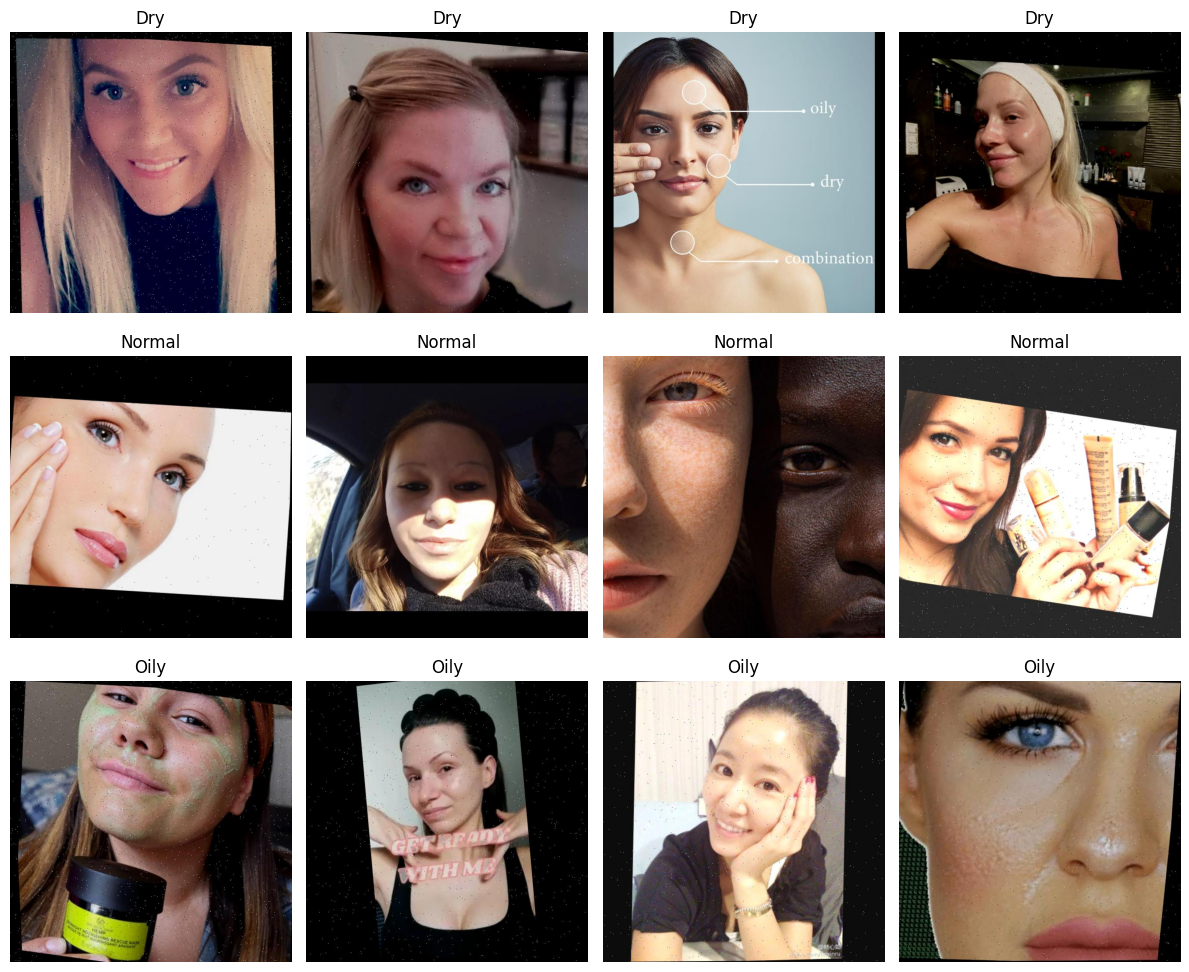

In [8]:

# VISUALIZE SAMPLE IMAGES


import matplotlib.pyplot as plt
from PIL import Image
import os
import random

classes = ["dry", "normal", "oily"]

fig, axes = plt.subplots(3, 4, figsize=(12, 10))

for row, class_name in enumerate(classes):

    class_path = os.path.join(base_path, "train", class_name)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
    ]

    # Select 4 random images from the class
    selected_images = random.sample(image_files, min(4, len(image_files)))

    for col, image_file in enumerate(selected_images):

        image_path = os.path.join(class_path, image_file)
        image = Image.open(image_path)

        axes[row, col].imshow(image)
        axes[row, col].set_title(class_name.capitalize())
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

##  Data Quality Assessment & Cleaning

Before training, the dataset is checked for image quality and
consistency. This includes identifying corrupted files, unusually
small images, and potential duplicate images.

The purpose of this step is to reduce data-quality problems that
could negatively affect model training and evaluation.

In [9]:

# DATA QUALITY ASSESSMENT


import os
from PIL import Image
from collections import Counter

# Dataset path
base_path = DATASET_PATH

# Supported image formats
image_extensions = (".jpg", ".jpeg", ".png", ".webp")

# Store information about the dataset
image_info = []
corrupted_images = []
small_images = []

# Minimum dimensions we consider suspicious
MIN_WIDTH = 100
MIN_HEIGHT = 100

# --------------------------------------------
# Scan all images
# --------------------------------------------

for split in ["train", "valid", "test"]:

    split_path = os.path.join(base_path, split)

    for class_name in os.listdir(split_path):

        class_path = os.path.join(split_path, class_name)

        if not os.path.isdir(class_path):
            continue

        for filename in os.listdir(class_path):

            if not filename.lower().endswith(image_extensions):
                continue

            image_path = os.path.join(class_path, filename)

            try:
                # Open image and verify that it can be read
                with Image.open(image_path) as img:

                    width, height = img.size
                    image_format = img.format

                    image_info.append({
                        "path": image_path,
                        "split": split,
                        "class": class_name,
                        "width": width,
                        "height": height,
                        "format": image_format
                    })

                    # Check for unusually small images
                    if width < MIN_WIDTH or height < MIN_HEIGHT:
                        small_images.append(image_path)

            except Exception as e:

                # Store files that cannot be opened
                corrupted_images.append({
                    "path": image_path,
                    "error": str(e)
                })


# --------------------------------------------
# Display results
# --------------------------------------------

print("=" * 50)
print("DATA QUALITY REPORT")
print("=" * 50)

print(f"\nTotal readable images: {len(image_info)}")
print(f"Corrupted/unreadable images: {len(corrupted_images)}")
print(f"Very small images: {len(small_images)}")

# --------------------------------------------
# Image dimensions
# --------------------------------------------

widths = [item["width"] for item in image_info]
heights = [item["height"] for item in image_info]

if widths and heights:

    print("\nImage dimensions:")
    print(f"Minimum width:  {min(widths)}")
    print(f"Maximum width:  {max(widths)}")
    print(f"Minimum height: {min(heights)}")
    print(f"Maximum height: {max(heights)}")

# --------------------------------------------
# Image formats
# --------------------------------------------

formats = Counter(item["format"] for item in image_info)

print("\nImage formats:")
for fmt, count in formats.items():
    print(f"  {fmt}: {count}")

# --------------------------------------------
# Corrupted files
# --------------------------------------------

if corrupted_images:

    print("\n Corrupted/unreadable files:")

    for item in corrupted_images[:10]:
        print(" ", item["path"])

    if len(corrupted_images) > 10:
        print(f"  ... and {len(corrupted_images) - 10} more")

else:

    print("\n✓ No corrupted images detected.")

# --------------------------------------------
# Small images
# --------------------------------------------

if small_images:

    print("\n Very small images:")

    for path in small_images[:10]:
        print(" ", path)

    if len(small_images) > 10:
        print(f"  ... and {len(small_images) - 10} more")

else:

    print("\n✓ No unusually small images detected.")

DATA QUALITY REPORT

Total readable images: 3152
Corrupted/unreadable images: 0
Very small images: 0

Image dimensions:
Minimum width:  640
Maximum width:  640
Minimum height: 640
Maximum height: 640

Image formats:
  JPEG: 3152

✓ No corrupted images detected.

✓ No unusually small images detected.


##  Label and Content Inspection

The dataset labels are visually inspected to identify obvious
mislabeled or unsuitable images, such as non-facial images,
graphics, advertisements, or images containing excessive
irrelevant content.

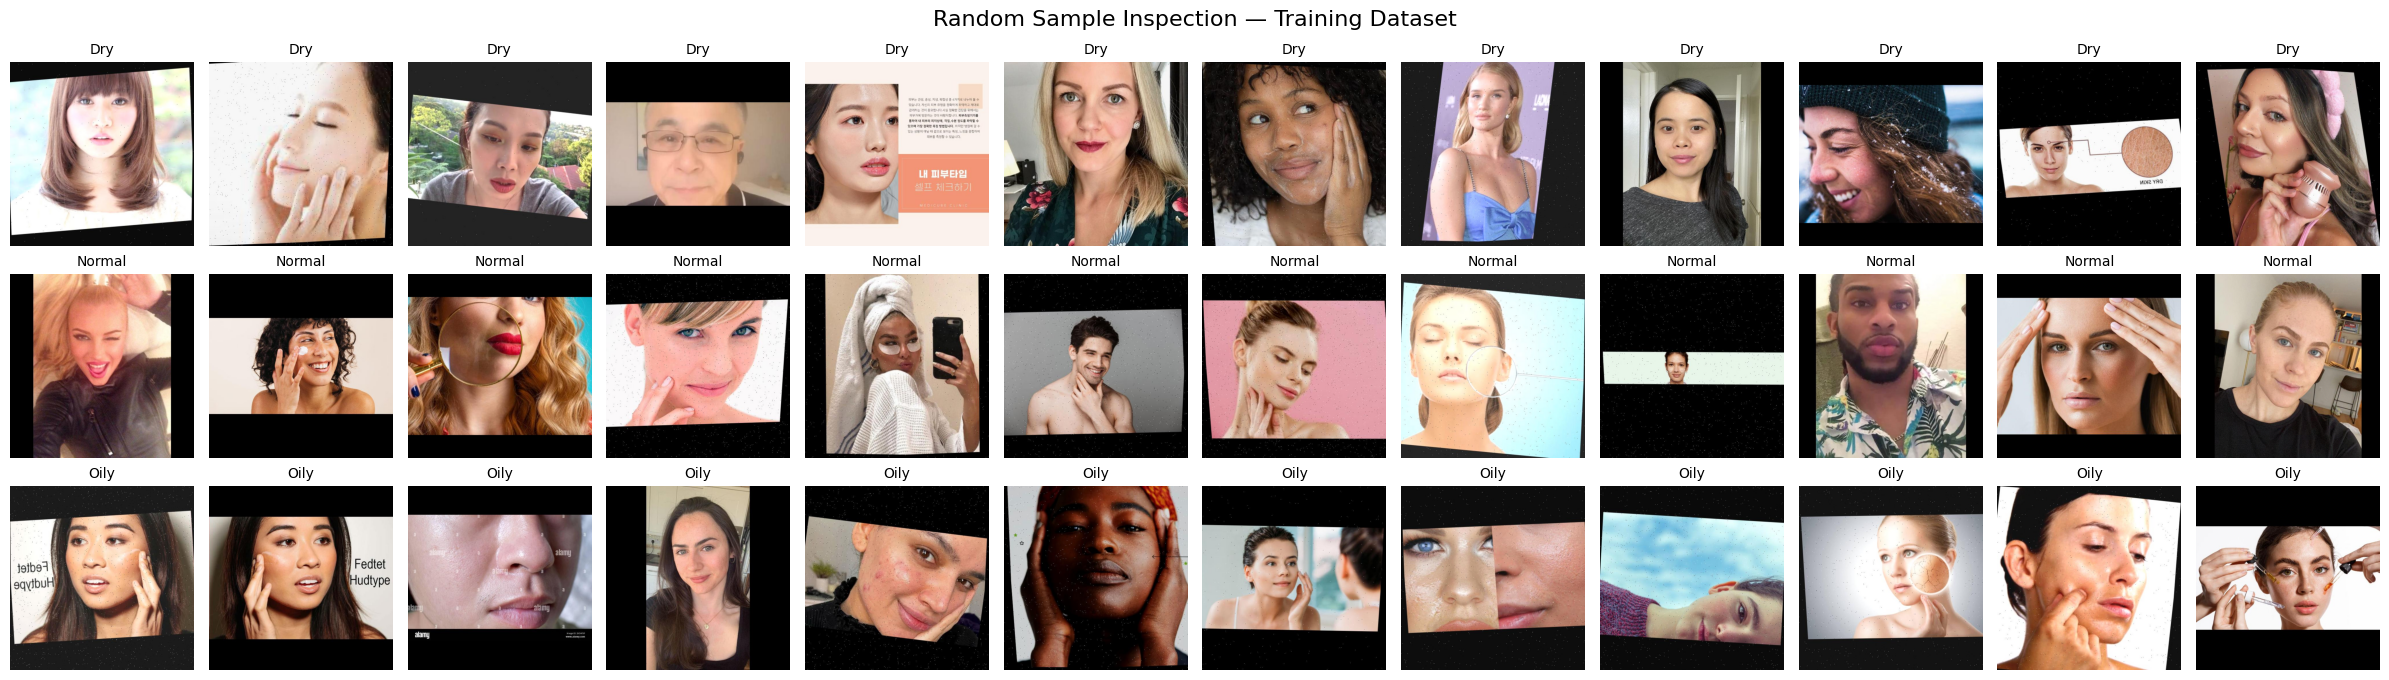

In [10]:

# LABEL & CONTENT INSPECTION


import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Number of images to inspect from each class
SAMPLES_PER_CLASS = 12

classes = ["dry", "normal", "oily"]

fig, axes = plt.subplots(
    len(classes),
    SAMPLES_PER_CLASS,
    figsize=(24, 7)
)

for row, class_name in enumerate(classes):

    class_path = os.path.join(base_path, "train", class_name)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
    ]

    # Randomly select images
    selected_images = random.sample(
        image_files,
        min(SAMPLES_PER_CLASS, len(image_files))
    )

    for col in range(SAMPLES_PER_CLASS):

        ax = axes[row, col]

        if col < len(selected_images):

            image_path = os.path.join(
                class_path,
                selected_images[col]
            )

            image = Image.open(image_path)

            ax.imshow(image)
            ax.set_title(class_name.capitalize(), fontsize=10)

        ax.axis("off")

plt.suptitle(
    "Random Sample Inspection — Training Dataset",
    fontsize=16
)

plt.tight_layout()
plt.show()



##  Face Detection and Dataset Filtering

Since the task focuses on facial skin-type classification, images
should contain a detectable human face.

A face-detection step is used to identify images that may not contain
a suitable facial region. These images are flagged for manual review
rather than being automatically deleted.

In [11]:

# FACE DETECTION CHECK


import cv2
import os
import matplotlib.pyplot as plt

# Load OpenCV's pre-trained face detector
face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

no_face_images = []
face_counts = {}

# --------------------------------------------
# Check every image
# --------------------------------------------

for split in ["train", "valid", "test"]:

    split_path = os.path.join(base_path, split)

    for class_name in os.listdir(split_path):

        class_path = os.path.join(split_path, class_name)

        if not os.path.isdir(class_path):
            continue

        count = 0

        for filename in os.listdir(class_path):

            if not filename.lower().endswith(
                (".jpg", ".jpeg", ".png", ".webp")
            ):
                continue

            image_path = os.path.join(class_path, filename)

            image = cv2.imread(image_path)

            if image is None:
                continue

            # Convert to grayscale
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

            # Detect faces
            faces = face_detector.detectMultiScale(
                gray,
                scaleFactor=1.1,
                minNeighbors=5,
                minSize=(80, 80)
            )

            count += 1

            # If no face is detected, flag the image
            if len(faces) == 0:

                no_face_images.append({
                    "path": image_path,
                    "split": split,
                    "class": class_name
                })

        face_counts[(split, class_name)] = count


# ============================================
# RESULTS
# ============================================

print("=" * 50)
print("FACE DETECTION REPORT")
print("=" * 50)

print(f"\nImages with no detected face: {len(no_face_images)}")

print("\nNo-face images by class:")

for class_name in ["dry", "normal", "oily"]:

    count = sum(
        1 for item in no_face_images
        if item["class"] == class_name
    )

    print(f"  {class_name}: {count}")


# Show first 20 flagged images
print("\nFirst flagged images:")

for item in no_face_images[:20]:
    print(
        f"  [{item['split']}] "
        f"{item['class']} → {os.path.basename(item['path'])}"
    )

FACE DETECTION REPORT

Images with no detected face: 1176

No-face images by class:
  dry: 289
  normal: 413
  oily: 474

First flagged images:
  [train] oily → oily_cab956597262566cf9fd_jpg.rf.e51da1d2224d4a59934cf39abc23d65b.jpg
  [train] oily → oily_cfecf350f8eca402121d_jpg.rf.5ea86b47966f2df08f2485786344a75a.jpg
  [train] oily → oily_7a071fda3e1e2d3ec0c7_jpg.rf.2c2dad9cad92baffc67fba75947cc36d.jpg
  [train] oily → oily_cf87f127ebe281a60a45_jpg.rf.d247b38fbdcf19ef9ec39f97447a189d.jpg
  [train] oily → oily_0997f02ba99a00439079_jpg.rf.f5bc95a68c6991000586e4d1adc44aeb.jpg
  [train] oily → oily_0889f3b817e44318b076_jpg.rf.046f71b102c41ea7cff1706eb1b2bd7c.jpg
  [train] oily → oily_fe6f60617df744bd42cd_jpg.rf.73d15a4ed6e42b926b690f45478191c4.jpg
  [train] oily → oily_73891f263bf4457d46f9_jpg.rf.4b5b9f8c6511c776d04ad220d7178c93.jpg
  [train] oily → oily_4f5c0cf14250da99f98a_jpg.rf.dfb10d6777d6fa167142b6880f6b66bc.jpg
  [train] oily → oily_3fe4adc9d6c9bcead953_jpg.rf.bce5cac9dc05df80fb70dd7

##  Review of Flagged Images

Images for which the initial face detector did not identify a face
are sampled and visually inspected.

The automated detector is used only to flag potentially problematic
images. Images are not removed automatically because face detection
may fail on valid facial images.
        

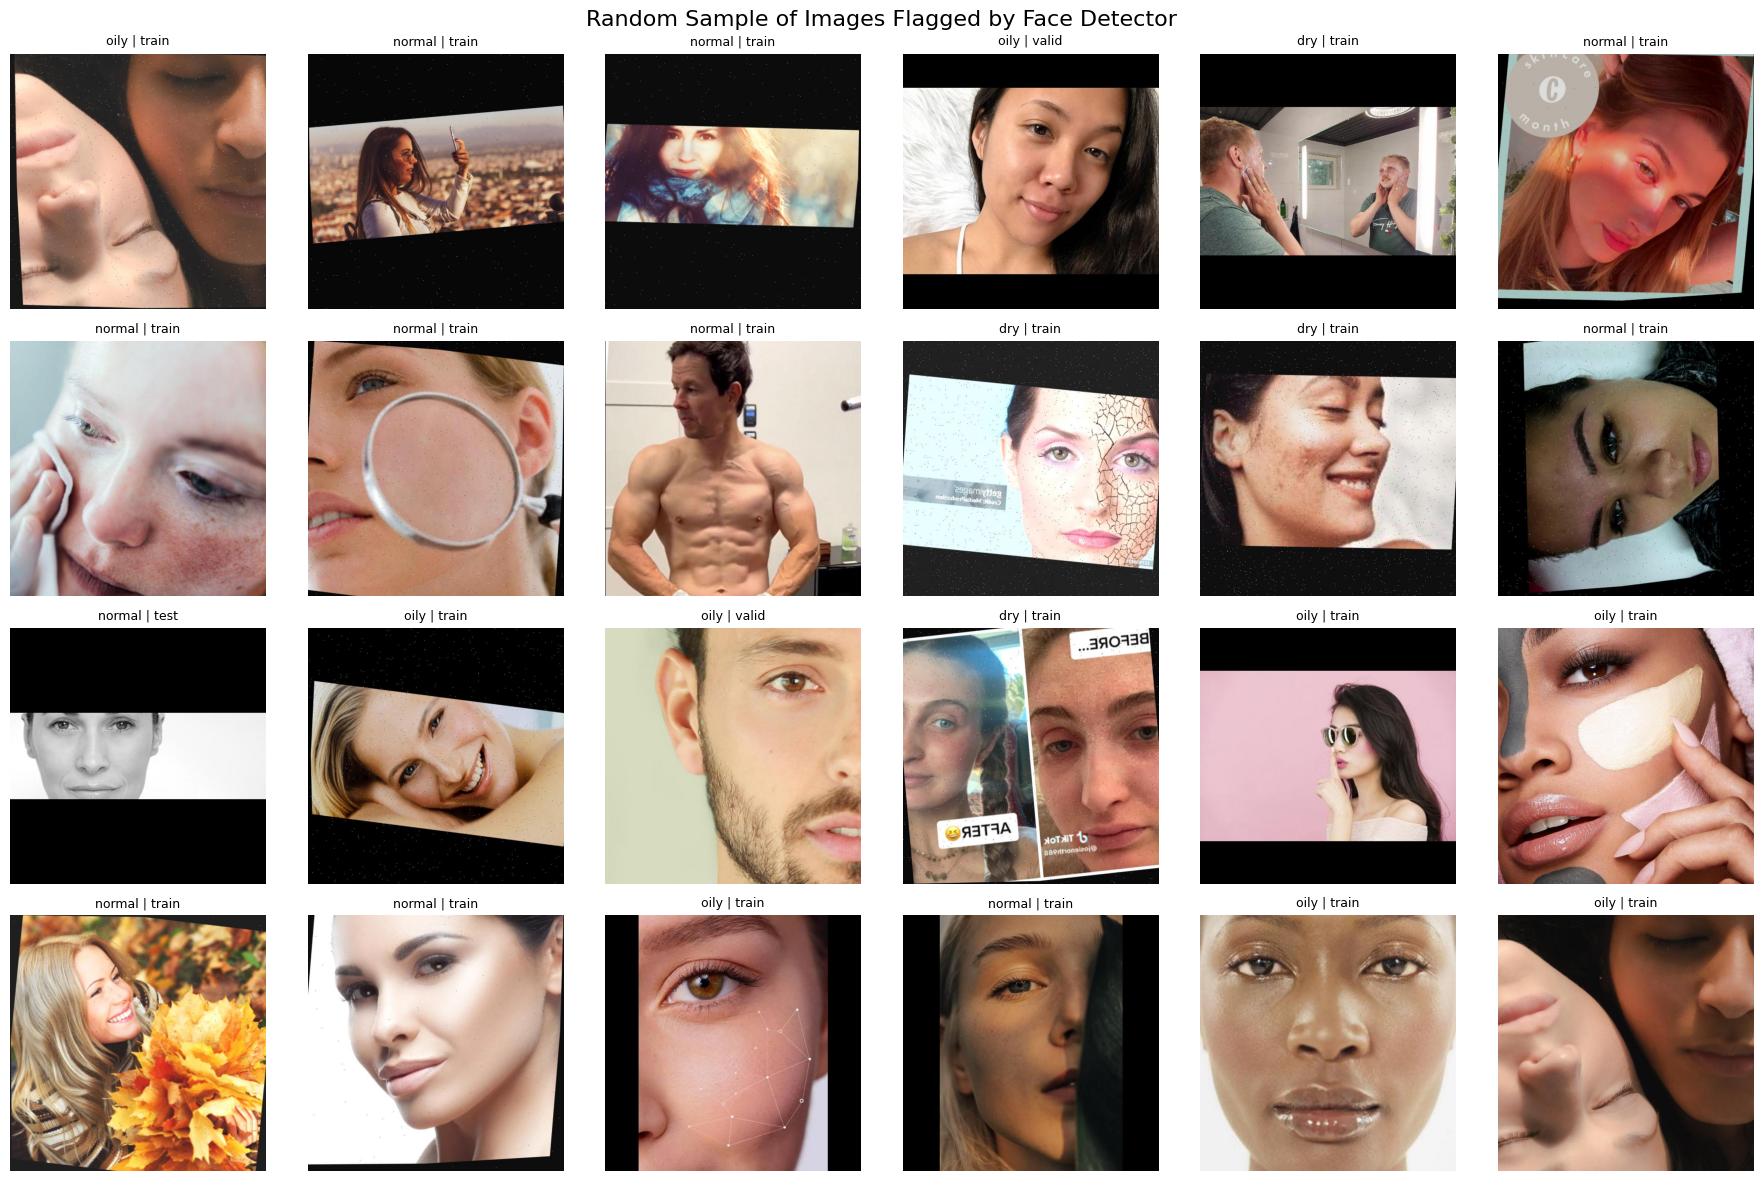

In [12]:

# VISUALIZE FLAGGED IMAGES


import matplotlib.pyplot as plt
from PIL import Image
import random
import os

# Number of flagged images to inspect
NUM_SAMPLES = 24

# Select random flagged images
samples = random.sample(
    no_face_images,
    min(NUM_SAMPLES, len(no_face_images))
)

fig, axes = plt.subplots(4, 6, figsize=(18, 12))

for ax, item in zip(axes.flat, samples):

    image_path = item["path"]

    try:
        image = Image.open(image_path)

        ax.imshow(image)
        ax.set_title(
            f"{item['class']} | {item['split']}",
            fontsize=9
        )

    except Exception:
        ax.set_title("Could not load")

    ax.axis("off")

plt.suptitle(
    "Random Sample of Images Flagged by Face Detector",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [13]:

# DUPLICATE IMAGE DETECTION


import os
import hashlib
from collections import defaultdict

# Store images grouped by their hash
image_hashes = defaultdict(list)

# --------------------------------------------
# Calculate MD5 hash for every image
# --------------------------------------------

for split in ["train", "valid", "test"]:

    split_path = os.path.join(base_path, split)

    for class_name in os.listdir(split_path):

        class_path = os.path.join(split_path, class_name)

        if not os.path.isdir(class_path):
            continue

        for filename in os.listdir(class_path):

            if not filename.lower().endswith(
                (".jpg", ".jpeg", ".png", ".webp")
            ):
                continue

            image_path = os.path.join(class_path, filename)

            try:

                with open(image_path, "rb") as f:
                    file_hash = hashlib.md5(
                        f.read()
                    ).hexdigest()

                image_hashes[file_hash].append({
                    "path": image_path,
                    "split": split,
                    "class": class_name
                })

            except Exception as e:

                print(
                    f"Could not process: {image_path}"
                )


# ============================================
# FIND DUPLICATES
# ============================================

duplicate_groups = [
    images
    for images in image_hashes.values()
    if len(images) > 1
]

duplicate_count = sum(
    len(group) - 1
    for group in duplicate_groups
)

print("=" * 50)
print("DUPLICATE IMAGE REPORT")
print("=" * 50)

print(f"\nUnique image files: {len(image_hashes)}")
print(f"Duplicate groups: {len(duplicate_groups)}")
print(f"Potential duplicate copies: {duplicate_count}")


# --------------------------------------------
# Show duplicate groups
# --------------------------------------------

if duplicate_groups:

    print("\nPotential duplicates:\n")

    for i, group in enumerate(duplicate_groups[:20], 1):

        print(f"Group {i}:")

        for item in group:
            print(
                f"  [{item['split']}] "
                f"{item['class']} → "
                f"{os.path.basename(item['path'])}"
            )

        print()

else:

    print("\n✓ No exact duplicate images detected.")

DUPLICATE IMAGE REPORT

Unique image files: 2728
Duplicate groups: 424
Potential duplicate copies: 424

Potential duplicates:

Group 1:
  [train] oily → oily_7a071fda3e1e2d3ec0c7_jpg.rf.2c2dad9cad92baffc67fba75947cc36d.jpg
  [train] oily → oily_7a071fda3e1e2d3ec0c7_jpg.rf.2c2dad9cad92baffc67fba75947cc36d - Copy.jpg

Group 2:
  [train] oily → oily_0997f02ba99a00439079_jpg.rf.f5bc95a68c6991000586e4d1adc44aeb.jpg
  [train] oily → oily_0997f02ba99a00439079_jpg.rf.f5bc95a68c6991000586e4d1adc44aeb - Copy.jpg

Group 3:
  [train] oily → oily_0889f3b817e44318b076_jpg.rf.046f71b102c41ea7cff1706eb1b2bd7c.jpg
  [train] oily → oily_0889f3b817e44318b076_jpg.rf.046f71b102c41ea7cff1706eb1b2bd7c - Copy.jpg

Group 4:
  [train] oily → oily_4e44fd089d5cb62f0655_jpg.rf.9ffcc277cb3c82e06e576fcb3d78deef - Copy.jpg
  [train] oily → oily_4e44fd089d5cb62f0655_jpg.rf.9ffcc277cb3c82e06e576fcb3d78deef.jpg

Group 5:
  [train] oily → oily_50b6ecef89abe40d5cb6_jpg.rf.d88bf3bce68d6fc6f3e579a3d772705f - Copy.jpg
  [tra

In [14]:

# CROSS-SPLIT DUPLICATE ANALYSIS


cross_split_duplicates = []

for group in duplicate_groups:

    splits = set(item["split"] for item in group)

    # More than one split means potential data leakage
    if len(splits) > 1:
        cross_split_duplicates.append(group)


print("=" * 50)
print("CROSS-SPLIT DUPLICATE REPORT")
print("=" * 50)

print(
    f"\nDuplicate groups across different splits: "
    f"{len(cross_split_duplicates)}"
)


if cross_split_duplicates:

    print("\n⚠️ Potential data leakage detected!\n")

    for i, group in enumerate(
        cross_split_duplicates[:20], 1
    ):

        print(f"Group {i}:")

        for item in group:

            print(
                f"  [{item['split']}] "
                f"{item['class']} → "
                f"{os.path.basename(item['path'])}"
            )

        print()

else:

    print(
        "\n✓ No exact duplicates were found "
        "across train/validation/test splits."
    )

CROSS-SPLIT DUPLICATE REPORT

Duplicate groups across different splits: 33

⚠️ Potential data leakage detected!

Group 1:
  [train] normal → normal_7d00a675b9fabb9780d8_jpg.rf.ebe87376b2c5a37f133daf0daddb9b4b.jpg
  [test] normal → normal_7d00a675b9fabb9780d8_jpg.rf.3ba7f8e5db8941144c0690dc2ce4b1e5.jpg

Group 2:
  [train] normal → normal_800b1d9bedd36765807a_jpg.rf.a1b338ca07a68df98effb1a7bee6c33b.jpg
  [test] normal → normal_800b1d9bedd36765807a_jpg.rf.9b5468927dbd3f46d17b8e2383d3c600.jpg

Group 3:
  [train] normal → normal_34458a38fc273ea6d641_jpg.rf.c0534c7d8558f8220239e172551c3b02.jpg
  [valid] normal → normal_34458a38fc273ea6d641_jpg.rf.983a08f686b01aaffc4c3448a04b8278.jpg

Group 4:
  [train] normal → normal_345dd34485c5ef28aeb8_jpg.rf.997acf467a1bb9cc8ebd042b5602cf9a.jpg
  [valid] normal → normal_345dd34485c5ef28aeb8_jpg.rf.7510e70e8d78d2a169192169a5037fd5.jpg

Group 5:
  [train] normal → normal_8e5e9ac3c56cdd16d6c7_jpg.rf.1a95e20a6b5373bfc03db690630c1b3b.jpg
  [valid] normal → no

##  Duplicate Removal and Dataset Cleaning

A cleaned copy of the dataset is created while preserving the
original dataset.

For exact duplicate images appearing across different splits,
the copy in the higher-priority split is retained:

Test > Validation > Train

This prevents data leakage while keeping the original data
available for reference.

For duplicates within the same split, one copy is retained.

## 2. Dataset Cleaning


In [15]:
# ============================================
# 8. CREATE CLEAN DATASET
# ============================================

import os
import shutil
import hashlib
from collections import defaultdict

# Original dataset
original_path = DATASET_PATH

# New cleaned dataset
clean_path = CLEAN_DATASET_PATH

# Remove previous clean copy if it exists
if os.path.exists(clean_path):
    shutil.rmtree(clean_path)

# Copy the complete original dataset
shutil.copytree(original_path, clean_path)

print("✓ Original dataset copied.")
print(f"Clean dataset: {clean_path}")


# ============================================
# FIND EXACT DUPLICATES
# ============================================

image_hashes = defaultdict(list)

for split in ["train", "valid", "test"]:

    split_path = os.path.join(clean_path, split)

    for class_name in os.listdir(split_path):

        class_path = os.path.join(split_path, class_name)

        if not os.path.isdir(class_path):
            continue

        for filename in os.listdir(class_path):

            if not filename.lower().endswith(
                (".jpg", ".jpeg", ".png", ".webp")
            ):
                continue

            image_path = os.path.join(
                class_path,
                filename
            )

            with open(image_path, "rb") as f:
                file_hash = hashlib.md5(
                    f.read()
                ).hexdigest()

            image_hashes[file_hash].append({
                "path": image_path,
                "split": split,
                "class": class_name
            })


# ============================================
# REMOVE DUPLICATES SAFELY
# ============================================

# Priority: test > valid > train
split_priority = {
    "test": 3,
    "valid": 2,
    "train": 1
}

files_removed = []
files_kept = []

for file_hash, group in image_hashes.items():

    # More than one copy
    if len(group) <= 1:
        files_kept.append(group[0])
        continue

    # Sort so that:
    # 1. Test has highest priority
    # 2. Validation comes second
    # 3. Train comes last
    # 4. Within the same split, keep the first file
    group_sorted = sorted(
        group,
        key=lambda x: -split_priority[x["split"]]
    )

    # Keep the first image
    keep = group_sorted[0]
    files_kept.append(keep)

    # Remove the remaining exact duplicates
    for duplicate in group_sorted[1:]:

        os.remove(duplicate["path"])

        files_removed.append({
            "removed": duplicate,
            "kept": keep
        })


# ============================================
# REPORT
# ============================================

print("\n" + "=" * 50)
print("CLEANING REPORT")
print("=" * 50)

print(f"\nOriginal images: 3152")
print(f"Duplicate copies removed: {len(files_removed)}")

print(
    f"Remaining images: "
    f"{3152 - len(files_removed)}"
)

print("\n✓ Original dataset was NOT modified.")
print("✓ Clean dataset created successfully.")

# ============================================
# SHOW CROSS-SPLIT REMOVALS
# ============================================

cross_split_removed = [
    item for item in files_removed
    if item["removed"]["split"] != item["kept"]["split"]
]

print(
    f"\nCross-split duplicates removed: "
    f"{len(cross_split_removed)}"
)

if cross_split_removed:

    print("\nExamples:")

    for item in cross_split_removed[:10]:

        print(
            f"Removed: "
            f"[{item['removed']['split']}] "
            f"{os.path.basename(item['removed']['path'])}"
        )

        print(
            f"Kept:    "
            f"[{item['kept']['split']}] "
            f"{os.path.basename(item['kept']['path'])}"
        )

        print()

✓ Original dataset copied.
Clean dataset: /content/clean_skin_dataset

CLEANING REPORT

Original images: 3152
Duplicate copies removed: 424
Remaining images: 2728

✓ Original dataset was NOT modified.
✓ Clean dataset created successfully.

Cross-split duplicates removed: 33

Examples:
Removed: [train] normal_7d00a675b9fabb9780d8_jpg.rf.ebe87376b2c5a37f133daf0daddb9b4b.jpg
Kept:    [test] normal_7d00a675b9fabb9780d8_jpg.rf.3ba7f8e5db8941144c0690dc2ce4b1e5.jpg

Removed: [train] normal_800b1d9bedd36765807a_jpg.rf.a1b338ca07a68df98effb1a7bee6c33b.jpg
Kept:    [test] normal_800b1d9bedd36765807a_jpg.rf.9b5468927dbd3f46d17b8e2383d3c600.jpg

Removed: [train] normal_34458a38fc273ea6d641_jpg.rf.c0534c7d8558f8220239e172551c3b02.jpg
Kept:    [valid] normal_34458a38fc273ea6d641_jpg.rf.983a08f686b01aaffc4c3448a04b8278.jpg

Removed: [train] normal_345dd34485c5ef28aeb8_jpg.rf.997acf467a1bb9cc8ebd042b5602cf9a.jpg
Kept:    [valid] normal_345dd34485c5ef28aeb8_jpg.rf.7510e70e8d78d2a169192169a5037fd5.jpg



In [16]:
# ============================================
# 9. VERIFY CLEAN DATASET
# ============================================

from collections import Counter
import os

print("=" * 55)
print("CLEAN DATASET DISTRIBUTION")
print("=" * 55)

total = 0

for split in ["train", "valid", "test"]:

    split_path = os.path.join(clean_path, split)

    counts = {}

    for class_name in ["dry", "normal", "oily"]:

        class_path = os.path.join(split_path, class_name)

        if os.path.exists(class_path):
            count = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
            ])
        else:
            count = 0

        counts[class_name] = count
        total += count

    print(f"\n{split.upper()}")
    for cls, count in counts.items():
        print(f"  {cls}: {count} images")

print("\n" + "-" * 55)
print(f"TOTAL CLEAN IMAGES: {total}")
print("-" * 55)

CLEAN DATASET DISTRIBUTION

TRAIN
  dry: 652 images
  normal: 1030 images
  oily: 655 images

VALID
  dry: 71 images
  normal: 107 images
  oily: 80 images

TEST
  dry: 35 images
  normal: 58 images
  oily: 40 images

-------------------------------------------------------
TOTAL CLEAN IMAGES: 2728
-------------------------------------------------------


In [17]:
# ============================================
# 10. CHECK FOR LABEL CONFLICTS
# ============================================

import os
import hashlib
from collections import defaultdict

original_path = DATASET_PATH

hash_labels = defaultdict(list)

for split in ["train", "valid", "test"]:

    split_path = os.path.join(original_path, split)

    for class_name in ["dry", "normal", "oily"]:

        class_path = os.path.join(split_path, class_name)

        for filename in os.listdir(class_path):

            if not filename.lower().endswith(
                (".jpg", ".jpeg", ".png", ".webp")
            ):
                continue

            image_path = os.path.join(class_path, filename)

            with open(image_path, "rb") as f:
                image_hash = hashlib.md5(f.read()).hexdigest()

            hash_labels[image_hash].append({
                "split": split,
                "class": class_name,
                "file": filename
            })


# Find images that have different labels
label_conflicts = []

for image_hash, items in hash_labels.items():

    labels = set(item["class"] for item in items)

    if len(labels) > 1:
        label_conflicts.append(items)


# ============================================
# REPORT
# ============================================

print("=" * 55)
print("LABEL CONFLICT REPORT")
print("=" * 55)

print(f"\nConflicting duplicate groups: {len(label_conflicts)}")

if len(label_conflicts) == 0:

    print("\n✓ No label conflicts detected.")
    print("✓ Every exact duplicate has a consistent label.")
    print("✓ Dataset is ready for preprocessing.")

else:

    print("\n⚠ LABEL CONFLICTS FOUND!")

    for i, group in enumerate(label_conflicts[:10], 1):

        print(f"\nConflict Group {i}:")

        for item in group:
            print(
                f"  [{item['split']}] "
                f"{item['class']} → "
                f"{item['file']}"
            )

LABEL CONFLICT REPORT

Conflicting duplicate groups: 0

✓ No label conflicts detected.
✓ Every exact duplicate has a consistent label.
✓ Dataset is ready for preprocessing.


##  Image Preprocessing

The cleaned dataset is prepared for deep learning.

- Images are resized to 224 × 224 pixels.
- Training images receive data augmentation to improve generalization.
- Validation and test images are not augmented.
- Pixel values are normalized.
- Separate data loaders are created for training, validation, and testing.

## 3. Image Preprocessing & Data Loaders


In [18]:

# 11. IMAGE PREPROCESSING & DATA LOADERS


import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# --------------------------------------------
# Configuration
# --------------------------------------------

DATASET_PATH = CLEAN_DATASET_PATH

IMAGE_SIZE = 224
BATCH_SIZE = 32

# Use GPU if available
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# --------------------------------------------
# Training transformations
# --------------------------------------------

train_transform = transforms.Compose([

    # Resize all images to the same size
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    # Mild augmentation
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),

    # Convert image to tensor
    transforms.ToTensor(),

    # Normalize pixel values
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# --------------------------------------------
# Validation / Test transformations
# --------------------------------------------

eval_transform = transforms.Compose([

    # Resize only
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    # Convert image to tensor
    transforms.ToTensor(),

    # Same normalization
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# --------------------------------------------
# Load datasets
# --------------------------------------------

train_dataset = datasets.ImageFolder(
    f"{DATASET_PATH}/train",
    transform=train_transform
)

valid_dataset = datasets.ImageFolder(
    f"{DATASET_PATH}/valid",
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    f"{DATASET_PATH}/test",
    transform=eval_transform
)


# --------------------------------------------
# Create DataLoaders
# --------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)


# --------------------------------------------
# Display information
# --------------------------------------------

print("\n" + "=" * 50)
print("DATA LOADER SUMMARY")
print("=" * 50)

print("Classes:", train_dataset.classes)

print(f"Training images:   {len(train_dataset)}")
print(f"Validation images: {len(valid_dataset)}")
print(f"Test images:       {len(test_dataset)}")

print(f"\nTraining batches:   {len(train_loader)}")
print(f"Validation batches: {len(valid_loader)}")
print(f"Test batches:       {len(test_loader)}")

print("\n✓ Preprocessing completed.")
print("✓ Training augmentation enabled.")
print("✓ Validation/test augmentation disabled.")

Device: cuda

DATA LOADER SUMMARY
Classes: ['dry', 'normal', 'oily']
Training images:   2337
Validation images: 258
Test images:       133

Training batches:   74
Validation batches: 9
Test batches:       5

✓ Preprocessing completed.
✓ Training augmentation enabled.
✓ Validation/test augmentation disabled.


##  Visualize Training Augmentation

A sample batch of training images is visualized to verify that
the preprocessing and augmentation pipeline is working correctly.

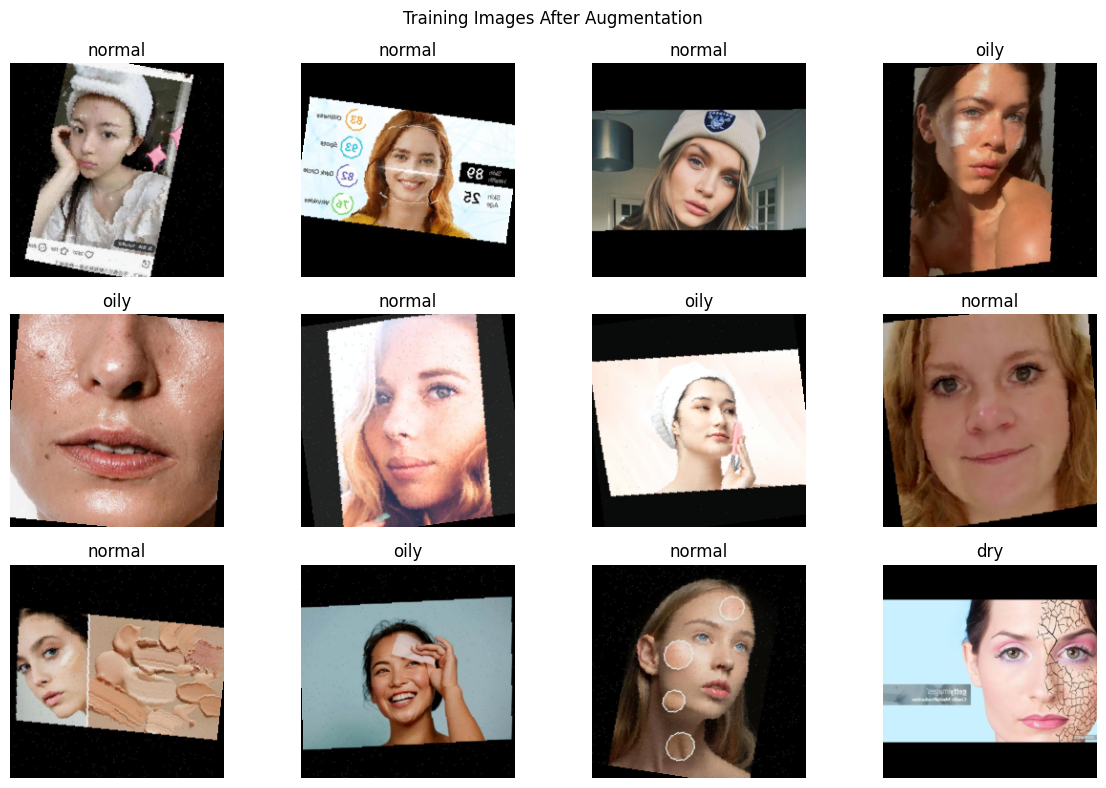

In [19]:

# 12. VISUALIZE TRAINING BATCH


import matplotlib.pyplot as plt
import numpy as np

# Get one batch
images, labels = next(iter(train_loader))

# Class names
class_names = train_dataset.classes

# Create figure
plt.figure(figsize=(12, 8))

for i in range(min(12, len(images))):

    # Convert tensor from CHW → HWC
    image = images[i].permute(1, 2, 0).numpy()

    # Undo normalization for visualization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image = image * std + mean

    # Keep values valid for display
    image = np.clip(image, 0, 1)

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)

    plt.title(class_names[labels[i].item()])
    plt.axis("off")

plt.suptitle("Training Images After Augmentation")
plt.tight_layout()
plt.show()

## 4. Data Quality / Content Verification


In [20]:
# ============================================
# 13. CONTENT QUALITY CHECK
# ============================================

import cv2
import os
import pandas as pd
from tqdm import tqdm

# --------------------------------------------
# Paths
# --------------------------------------------

DATASET_PATH = CLEAN_DATASET_PATH

# Store results
quality_results = []

# --------------------------------------------
# Load OpenCV face detector
# --------------------------------------------

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

# --------------------------------------------
# Analyze every image
# --------------------------------------------

for split in ["train", "valid", "test"]:

    split_path = os.path.join(DATASET_PATH, split)

    for class_name in ["dry", "normal", "oily"]:

        class_path = os.path.join(split_path, class_name)

        image_files = [
            f for f in os.listdir(class_path)
            if f.lower().endswith(
                (".jpg", ".jpeg", ".png", ".webp")
            )
        ]

        for filename in tqdm(
            image_files,
            desc=f"{split}/{class_name}"
        ):

            image_path = os.path.join(
                class_path,
                filename
            )

            image = cv2.imread(image_path)

            # Skip unreadable images
            if image is None:
                quality_results.append({
                    "split": split,
                    "class": class_name,
                    "filename": filename,
                    "path": image_path,
                    "face_count": -1,
                    "face_ratio": 0,
                    "black_border_ratio": 0,
                    "flag": "unreadable"
                })
                continue

            height, width = image.shape[:2]

            # --------------------------------
            # Face detection
            # --------------------------------

            gray = cv2.cvtColor(
                image,
                cv2.COLOR_BGR2GRAY
            )

            faces = face_cascade.detectMultiScale(
                gray,
                scaleFactor=1.1,
                minNeighbors=5,
                minSize=(50, 50)
            )

            face_count = len(faces)

            # Largest detected face
            largest_face_area = 0

            for (x, y, w, h) in faces:
                area = w * h

                if area > largest_face_area:
                    largest_face_area = area

            image_area = width * height

            face_ratio = (
                largest_face_area / image_area
                if image_area > 0
                else 0
            )

            # --------------------------------
            # Estimate black-border ratio
            # --------------------------------

            gray_small = cv2.resize(
                gray,
                (100, 100)
            )

            black_pixels = np.sum(
                gray_small < 10
            )

            black_border_ratio = (
                black_pixels / gray_small.size
            )

            # --------------------------------
            # Determine flags
            # --------------------------------

            flags = []

            if face_count == 0:
                flags.append("no_face")

            elif face_count > 1:
                flags.append("multiple_faces")

            # Face occupies less than 8% of image
            if face_count >= 1 and face_ratio < 0.08:
                flags.append("small_face")

            # More than 35% near-black pixels
            if black_border_ratio > 0.35:
                flags.append("large_black_area")

            flag = (
                "OK"
                if len(flags) == 0
                else ";".join(flags)
            )

            quality_results.append({
                "split": split,
                "class": class_name,
                "filename": filename,
                "path": image_path,
                "face_count": face_count,
                "face_ratio": round(face_ratio, 4),
                "black_border_ratio": round(
                    black_border_ratio, 4
                ),
                "flag": flag
            })


# --------------------------------------------
# Create DataFrame
# --------------------------------------------

quality_df = pd.DataFrame(quality_results)

# Save report
report_path = "/content/content_quality_report.csv"

quality_df.to_csv(
    report_path,
    index=False
)


# ============================================
# REPORT
# ============================================

print("\n" + "=" * 55)
print("CONTENT QUALITY REPORT")
print("=" * 55)

print(f"\nTotal images checked: {len(quality_df)}")

print("\nFlag summary:")

flag_counts = (
    quality_df["flag"]
    .value_counts()
)

print(flag_counts)

print("\nImages requiring review:")

review_count = (
    quality_df["flag"] != "OK"
).sum()

print(f"{review_count} images flagged")

print(f"\nReport saved to:")
print(report_path)

print("\n✓ No images were deleted.")
print("✓ Flagged images will be reviewed before removal.")

test/oily: 100%|██████████| 40/40 [00:03<00:00, 10.05it/s]



CONTENT QUALITY REPORT

Total images checked: 2728

Flag summary:
flag
OK                                            952
no_face                                       675
large_black_area                              362
no_face;large_black_area                      245
small_face                                    194
small_face;large_black_area                   118
multiple_faces                                109
multiple_faces;large_black_area                37
multiple_faces;small_face                      24
multiple_faces;small_face;large_black_area     12
Name: count, dtype: int64

Images requiring review:
1776 images flagged

Report saved to:
/content/content_quality_report.csv

✓ No images were deleted.
✓ Flagged images will be reviewed before removal.


## 5. CNN Baseline


In [21]:

#  BASELINE CNN MODEL
# Skin Type Classification: Dry / Normal / Oily

import torch
import torch.nn as nn
import torch.optim as optim

# ------------------------------------------------------------
# 1. Define the device
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)


# ------------------------------------------------------------
# 2. Define the CNN architecture
# ------------------------------------------------------------

class SkinTypeCNN(nn.Module):

    def __init__(self, num_classes=3):
        super(SkinTypeCNN, self).__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Adaptive pooling means we don't have to manually
        # calculate the flattened image size.
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(128, num_classes)
        )


    def forward(self, x):

        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)

        return x


# ------------------------------------------------------------
# 3. Create the model
# ------------------------------------------------------------

model = SkinTypeCNN(num_classes=3).to(device)

print("\nModel created successfully!")
print(model)


# ------------------------------------------------------------
# 4. Loss function
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss()


# ------------------------------------------------------------
# 5. Optimizer
# ------------------------------------------------------------

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)


# ------------------------------------------------------------
# 6. Show number of trainable parameters
# ------------------------------------------------------------

total_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("\nTrainable parameters:", f"{total_params:,}")

In [22]:

# MODEL TRAINING

import copy
import time

# ------------------------------------------------------------
# Training settings
# ------------------------------------------------------------

NUM_EPOCHS = 20

best_val_accuracy = 0.0
best_model_weights = copy.deepcopy(model.state_dict())

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []


# ------------------------------------------------------------
# Training loop
# ------------------------------------------------------------

print("=" * 60)
print("STARTING MODEL TRAINING")
print("=" * 60)

start_time = time.time()


for epoch in range(NUM_EPOCHS):

    # ========================================================
    # TRAINING
    # ========================================================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update model parameters
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()


    epoch_train_loss = running_loss / total
    epoch_train_accuracy = correct / total


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    # No gradients needed during validation
    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()


    epoch_val_loss = running_loss / total
    epoch_val_accuracy = correct / total


    # ========================================================
    # SAVE HISTORY
    # ========================================================

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    train_accuracies.append(epoch_train_accuracy)
    val_accuracies.append(epoch_val_accuracy)


    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if epoch_val_accuracy > best_val_accuracy:

        best_val_accuracy = epoch_val_accuracy

        best_model_weights = copy.deepcopy(model.state_dict())

        torch.save(
            best_model_weights,
            "/content/best_skin_type_cnn.pth"
        )

        best_marker = " ⭐ BEST"

    else:
        best_marker = ""


    # ========================================================
    # PRINT RESULTS
    # ========================================================

    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_accuracy * 100:.2f}% | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_accuracy * 100:.2f}%"
        f"{best_marker}"
    )


# ------------------------------------------------------------
# Restore the best model
# ------------------------------------------------------------

model.load_state_dict(best_model_weights)

elapsed_time = time.time() - start_time


print("\n" + "=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)

print(f"Best validation accuracy: {best_val_accuracy * 100:.2f}%")
print(f"Training time: {elapsed_time / 60:.2f} minutes")
print("Best model saved to:")
print("/content/best_skin_type_cnn.pth")

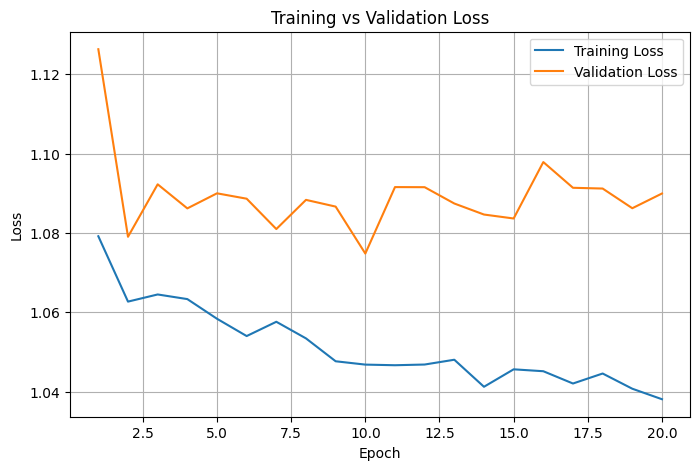

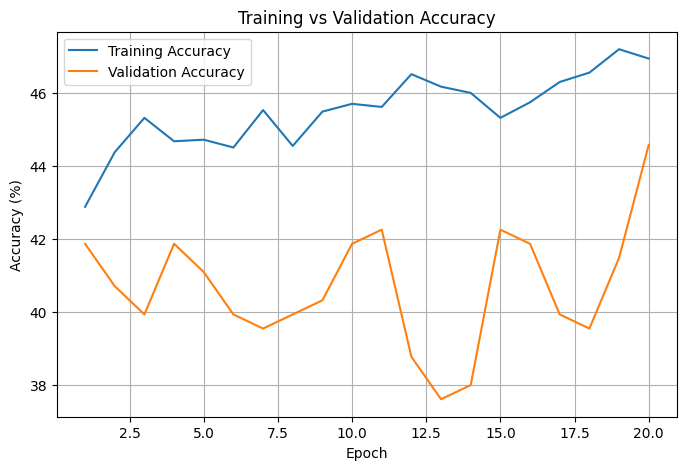

In [23]:

# TRAINING CURVES


import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)


# ------------------------------------------------------------
# 1. Loss Curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(epochs, train_losses, label="Training Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()


# ------------------------------------------------------------
# 2. Accuracy Curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    [x * 100 for x in train_accuracies],
    label="Training Accuracy"
)

plt.plot(
    epochs,
    [x * 100 for x in val_accuracies],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

##  ResNet18 Transfer Learning

A pretrained ResNet18 model is used as a feature extractor.
The original ImageNet classification layer is replaced with
a new classifier for the three skin-type classes:

- Dry
- Normal
- Oily

Initially, the pretrained ResNet18 layers are frozen and only
the new classification layer is trained.

## 6. ResNet18 Transfer Learning


In [24]:

# RESNET18 TRANSFER LEARNING

import torch
import torch.nn as nn
from torchvision import models


# 1. Load pretrained ResNet18


resnet_model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

print("Pretrained ResNet18 loaded successfully.")


# ------------------------------------------------------------
# 2. Freeze the pretrained layers
# ------------------------------------------------------------

for parameter in resnet_model.parameters():
    parameter.requires_grad = False


# ------------------------------------------------------------
# 3. Replace the original classifier
# ------------------------------------------------------------

# ResNet18's original classifier has 512 input features.
# We replace the ImageNet classifier with our 3-class classifier.

num_features = resnet_model.fc.in_features

resnet_model.fc = nn.Sequential(
    nn.Linear(num_features, 128),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(128, 3)
)


# ------------------------------------------------------------
# 4. Move model to GPU
# ------------------------------------------------------------

resnet_model = resnet_model.to(device)


# ------------------------------------------------------------
# 5. Define loss function
# ------------------------------------------------------------

resnet_criterion = nn.CrossEntropyLoss()


# ------------------------------------------------------------
# 6. Optimizer
# ------------------------------------------------------------

# Only the new classifier is trainable at this stage.

resnet_optimizer = torch.optim.Adam(
    resnet_model.fc.parameters(),
    lr=0.001,
    weight_decay=1e-4
)


# ------------------------------------------------------------
# 7. Count trainable parameters
# ------------------------------------------------------------

trainable_params = sum(
    p.numel()
    for p in resnet_model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in resnet_model.parameters()
)

print("\n" + "=" * 55)
print("RESNET18 MODEL SUMMARY")
print("=" * 55)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

print("\nOutput classes:")
print(train_dataset.classes)

print("\n✓ Pretrained layers frozen.")
print("✓ New 3-class classifier created.")
print("✓ Model moved to:", device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 184MB/s]


Pretrained ResNet18 loaded successfully.

RESNET18 MODEL SUMMARY
Total parameters:     11,242,563
Trainable parameters: 66,051

Output classes:
['dry', 'normal', 'oily']

✓ Pretrained layers frozen.
✓ New 3-class classifier created.
✓ Model moved to: cuda


##  Train ResNet18

The pretrained ResNet18 backbone is kept frozen during this
initial transfer-learning stage. Only the newly added classifier
is optimized for the three skin-type classes.

Training and validation performance are monitored across epochs,
and the model with the best validation accuracy is saved.

In [27]:
# ============================================================
# TRAIN RESNET18
# ============================================================

import time
import copy
import torch

# ------------------------------------------------------------
# Training settings
# ------------------------------------------------------------

num_epochs = 20

best_val_accuracy = 0.0
best_resnet_state = None

resnet_history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": []
}

start_time = time.time()


# ------------------------------------------------------------
# Training loop
# ------------------------------------------------------------

for epoch in range(num_epochs):

    # =========================
    # TRAINING
    # =========================

    resnet_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        resnet_optimizer.zero_grad()

        outputs = resnet_model(images)

        loss = resnet_criterion(outputs, labels)

        loss.backward()

        resnet_optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_accuracy = 100 * correct / total


    # =========================
    # VALIDATION
    # =========================

    resnet_model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        # IMPORTANT:
        # Your notebook uses valid_loader, not val_loader.

        for images, labels in valid_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = resnet_model(images)

            loss = resnet_criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / val_total
    val_accuracy = 100 * val_correct / val_total


    # =========================
    # SAVE HISTORY
    # =========================

    resnet_history["train_loss"].append(train_loss)
    resnet_history["val_loss"].append(val_loss)

    resnet_history["train_accuracy"].append(train_accuracy)
    resnet_history["val_accuracy"].append(val_accuracy)


    # =========================
    # SAVE BEST MODEL
    # =========================

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        best_resnet_state = copy.deepcopy(
            resnet_model.state_dict()
        )

        torch.save(
            best_resnet_state,
            os.path.join(CHECKPOINT_DIR, "best_resnet18_skin_type.pth")
        )

        best_marker = " ⭐ BEST"

    else:
        best_marker = ""


    # =========================
    # PRINT RESULTS
    # =========================

    print(
        f"Epoch [{epoch + 1:02d}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2f}%"
        f"{best_marker}"
    )


# ------------------------------------------------------------
# Restore best model
# ------------------------------------------------------------

resnet_model.load_state_dict(best_resnet_state)


# ------------------------------------------------------------
# Training summary
# ------------------------------------------------------------

training_time = (time.time() - start_time) / 60

print("\n" + "=" * 60)
print("RESNET18 TRAINING COMPLETE")
print("=" * 60)

print(f"Best validation accuracy: {best_val_accuracy:.2f}%")
print(f"Training time: {training_time:.2f} minutes")

print("\nBest model saved to:")
print(os.path.join(CHECKPOINT_DIR, "best_resnet18_skin_type.pth"))

print("\n✓ Best model restored.")
print("✓ Training history saved.")

## 7. Experiment 1 — ResNet18 Baseline


In [34]:
# ============================================================
# EXPERIMENT 1 — RESNET18 BASELINE TEST
# ============================================================

import torch
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Make sure model is in evaluation mode
resnet18_test.eval()

test_loss = 0.0
correct = 0
total = 0

all_predictions = []
all_labels = []

criterion = torch.nn.CrossEntropyLoss()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet18_test(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)

        _, predictions = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


# Calculate results
test_loss = test_loss / total
test_accuracy = correct / total

print("=" * 60)
print("EXPERIMENT 1 — RESNET18 BASELINE TEST")
print("=" * 60)

print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_predictions))

EXPERIMENT 1 — RESNET18 BASELINE TEST
Test Loss:     1.1425
Test Accuracy: 29.32%

Classification Report:
              precision    recall  f1-score   support

         dry     0.2200    0.3143    0.2588        35
      normal     0.5000    0.0345    0.0645        58
        oily     0.3291    0.6500    0.4370        40

    accuracy                         0.2932       133
   macro avg     0.3497    0.3329    0.2534       133
weighted avg     0.3749    0.2932    0.2277       133


Confusion Matrix:
[[11  2 22]
 [25  2 31]
 [14  0 26]]


## 8. Experiment 2 — Fine-Tuning


In [35]:

# EXPERIMENT 2 — RESNET18 FINE-TUNING


import torch
import torch.nn as nn
from torchvision import models

# ------------------------------------------------------------
# 1. Load pretrained ResNet18
# ------------------------------------------------------------

resnet18_ft = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# ------------------------------------------------------------
# 2. Replace classifier
#    SAME architecture used for the original checkpoint
# ------------------------------------------------------------

resnet18_ft.fc = nn.Sequential(
    nn.Linear(resnet18_ft.fc.in_features, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 3)
)

# ------------------------------------------------------------
# 3. Load our previously trained checkpoint
# ------------------------------------------------------------

checkpoint = torch.load(
    os.path.join(CHECKPOINT_DIR, "best_resnet18_skin_type.pth"),
    map_location=device
)

if "model_state_dict" in checkpoint:
    checkpoint = checkpoint["model_state_dict"]

resnet18_ft.load_state_dict(checkpoint, strict=True)

# ------------------------------------------------------------
# 4. Freeze everything first
# ------------------------------------------------------------

for param in resnet18_ft.parameters():
    param.requires_grad = False

# ------------------------------------------------------------
# 5. Unfreeze Layer 4 + classifier
# ------------------------------------------------------------

for param in resnet18_ft.layer4.parameters():
    param.requires_grad = True

for param in resnet18_ft.fc.parameters():
    param.requires_grad = True

# ------------------------------------------------------------
# 6. Move to GPU
# ------------------------------------------------------------

resnet18_ft = resnet18_ft.to(device)

# ------------------------------------------------------------
# 7. Check trainable parameters
# ------------------------------------------------------------

trainable = sum(
    p.numel()
    for p in resnet18_ft.parameters()
    if p.requires_grad
)

total = sum(
    p.numel()
    for p in resnet18_ft.parameters()
)

print("=" * 60)
print("EXPERIMENT 2 — RESNET18 FINE-TUNING")
print("=" * 60)

print(f"Total parameters:      {total:,}")
print(f"Trainable parameters:  {trainable:,}")

print("\nTrainable layers:")
print("✓ ResNet18 Layer 4")
print("✓ Final classifier")
print("✓ Earlier layers frozen")

EXPERIMENT 2 — RESNET18 FINE-TUNING
Total parameters:      11,242,563
Trainable parameters:  8,459,779

Trainable layers:
✓ ResNet18 Layer 4
✓ Final classifier
✓ Earlier layers frozen


In [36]:
# ============================================================
# EXPERIMENT 2 — RESNET18 FINE-TUNING TRAINING
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import time
import copy

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

NUM_EPOCHS = 20
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, resnet18_ft.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# ------------------------------------------------------------
# Tracking
# ------------------------------------------------------------

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_accuracy = 0.0
best_model_weights = copy.deepcopy(resnet18_ft.state_dict())

start_time = time.time()

print("=" * 60)
print("EXPERIMENT 2 — RESNET18 FINE-TUNING TRAINING")
print("=" * 60)

print(f"Epochs:        {NUM_EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Weight decay:  {WEIGHT_DECAY}")
print("=" * 60)

# ============================================================
# TRAINING LOOP
# ============================================================

for epoch in range(NUM_EPOCHS):

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    resnet18_ft.train()

    # Keep frozen BatchNorm layers in evaluation mode
    for module in resnet18_ft.modules():
        if isinstance(module, nn.BatchNorm2d):
            if not any(p.requires_grad for p in module.parameters()):
                module.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = resnet18_ft(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predictions = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

    epoch_train_loss = running_loss / total
    epoch_train_accuracy = correct / total

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    resnet18_ft.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = resnet18_ft(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            _, predictions = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predictions == labels).sum().item()

    epoch_val_loss = running_val_loss / val_total
    epoch_val_accuracy = val_correct / val_total

    # --------------------------------------------------------
    # Save history
    # --------------------------------------------------------

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    train_accuracies.append(epoch_train_accuracy)
    val_accuracies.append(epoch_val_accuracy)

    # --------------------------------------------------------
    # Save best model
    # --------------------------------------------------------

    if epoch_val_accuracy > best_val_accuracy:

        best_val_accuracy = epoch_val_accuracy

        best_model_weights = copy.deepcopy(
            resnet18_ft.state_dict()
        )

        torch.save(
            best_model_weights,
            os.path.join(CHECKPOINT_DIR, "best_resnet18_finetuned.pth")
        )

        best_marker = " ⭐ BEST"

    else:
        best_marker = ""

    # --------------------------------------------------------
    # Print results
    # --------------------------------------------------------

    print(
        f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_accuracy*100:.2f}% | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_accuracy*100:.2f}%"
        f"{best_marker}"
    )


# ============================================================
# RESTORE BEST MODEL
# ============================================================

resnet18_ft.load_state_dict(best_model_weights)

training_time = (time.time() - start_time) / 60

print("\n" + "=" * 60)
print("EXPERIMENT 2 — TRAINING COMPLETE")
print("=" * 60)

print(f"Best validation accuracy: {best_val_accuracy*100:.2f}%")
print(f"Training time:            {training_time:.2f} minutes")
print("Best model saved to:")
print(os.path.join(CHECKPOINT_DIR, "best_resnet18_finetuned.pth"))
print("✓ Best model restored")

## 9. Experiment 3 — Stronger Regularization


In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import copy
import time
import matplotlib.pyplot as plt

# ============================================================
# EXPERIMENT 3 — STRONGER REGULARIZATION
# ============================================================

print("=" * 60)
print("EXPERIMENT 3 — RESNET18 STRONGER REGULARIZATION")
print("=" * 60)

# ------------------------------------------------------------
# 1. Device
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


# ------------------------------------------------------------
# 2. Create pretrained ResNet18
# ------------------------------------------------------------

resnet18_exp3 = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

# ------------------------------------------------------------
# 3. Freeze the entire backbone first
# ------------------------------------------------------------

for param in resnet18_exp3.parameters():
    param.requires_grad = False


# ------------------------------------------------------------
# 4. Controlled fine-tuning
#    Only Layer 4 is trainable
# ------------------------------------------------------------

for param in resnet18_exp3.layer4.parameters():
    param.requires_grad = True


# ------------------------------------------------------------
# 5. Replace classifier with stronger dropout
# ------------------------------------------------------------

num_features = resnet18_exp3.fc.in_features

resnet18_exp3.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(num_features, 128),
    nn.ReLU(),
    nn.Dropout(p=0.4),
    nn.Linear(128, 3)
)

# New classifier must be trainable
for param in resnet18_exp3.fc.parameters():
    param.requires_grad = True


# ------------------------------------------------------------
# 6. Move model to GPU
# ------------------------------------------------------------

resnet18_exp3 = resnet18_exp3.to(device)


# ------------------------------------------------------------
# 7. Label-smoothing Cross Entropy
# ------------------------------------------------------------

criterion_exp3 = nn.CrossEntropyLoss(
    label_smoothing=0.1
)


# ------------------------------------------------------------
# 8. Optimizer with weight decay
# ------------------------------------------------------------

optimizer_exp3 = optim.AdamW(
    filter(lambda p: p.requires_grad, resnet18_exp3.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)


# ------------------------------------------------------------
# 9. Learning-rate scheduler
# ------------------------------------------------------------

scheduler_exp3 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_exp3,
    mode="max",
    factor=0.5,
    patience=3
)


# ------------------------------------------------------------
# 10. Show trainable parameters
# ------------------------------------------------------------

total_params = sum(
    p.numel() for p in resnet18_exp3.parameters()
)

trainable_params = sum(
    p.numel()
    for p in resnet18_exp3.parameters()
    if p.requires_grad
)

print(f"\nTotal parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

print("\nTrainable layers:")
print("✓ ResNet18 Layer 4")
print("✓ Regularized classifier")
print("✓ Earlier layers frozen")
print("✓ Label smoothing = 0.1")
print("✓ Weight decay = 1e-4")
print("✓ Dropout = 0.5 / 0.4")


# ============================================================
# 11. Training
# ============================================================

num_epochs = 20

best_val_acc = 0.0
best_model_state = None

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

start_time = time.time()

print("\n" + "=" * 60)
print("STARTING EXPERIMENT 3 TRAINING")
print("=" * 60)


for epoch in range(num_epochs):

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    resnet18_exp3.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer_exp3.zero_grad()

        outputs = resnet18_exp3(images)

        loss = criterion_exp3(outputs, labels)

        loss.backward()

        optimizer_exp3.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_acc = correct / total


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    resnet18_exp3.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = resnet18_exp3(images)

            loss = criterion_exp3(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total


    # --------------------------------------------------------
    # Scheduler
    # --------------------------------------------------------

    scheduler_exp3.step(val_acc)


    # --------------------------------------------------------
    # Store history
    # --------------------------------------------------------

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)


    # --------------------------------------------------------
    # Save best model
    # --------------------------------------------------------

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        best_model_state = copy.deepcopy(
            resnet18_exp3.state_dict()
        )

        torch.save(
            best_model_state,
            os.path.join(CHECKPOINT_DIR, "best_resnet18_regularized.pth")
        )


    # --------------------------------------------------------
    # Print epoch results
    # --------------------------------------------------------

    current_lr = optimizer_exp3.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch+1:02d}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc*100:.2f}% | "
        f"LR: {current_lr:.2e}"
    )


# ============================================================
# 12. Restore best model
# ============================================================

resnet18_exp3.load_state_dict(best_model_state)

training_time = (time.time() - start_time) / 60

print("\n" + "=" * 60)
print("EXPERIMENT 3 — TRAINING COMPLETE")
print("=" * 60)

print(f"Best validation accuracy: {best_val_acc*100:.2f}%")
print(f"Training time: {training_time:.2f} minutes")

print("\nBest model saved to:")
print(os.path.join(CHECKPOINT_DIR, "best_resnet18_regularized.pth"))

print("\n✓ Best model restored")

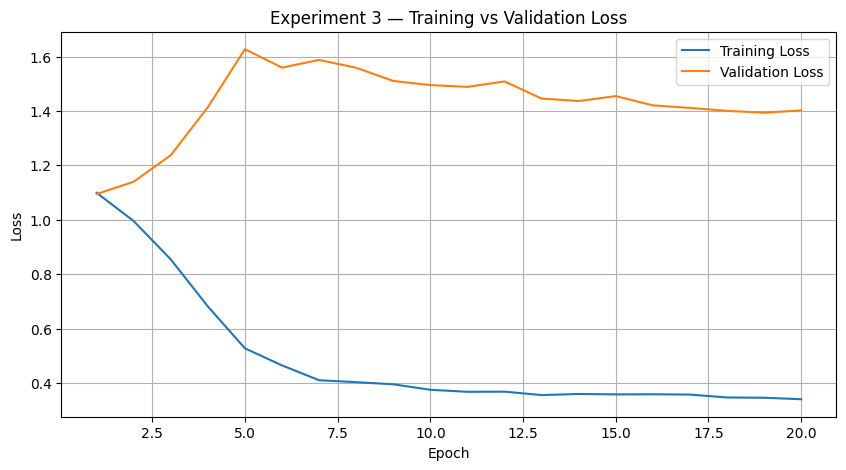

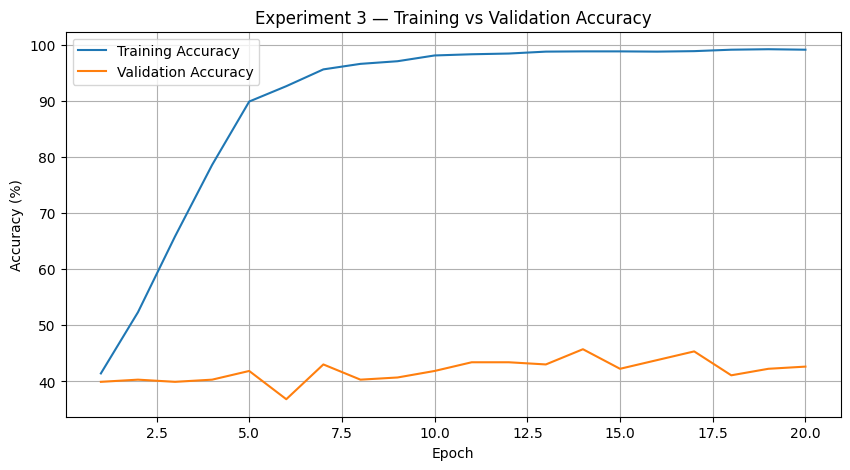

In [38]:
# ============================================================
# EXPERIMENT 3 — TRAINING CURVES
# ============================================================

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(10, 5))

plt.plot(
    epochs,
    train_losses,
    label="Training Loss"
)

plt.plot(
    epochs,
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment 3 — Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()


plt.figure(figsize=(10, 5))

plt.plot(
    epochs,
    [x * 100 for x in train_accuracies],
    label="Training Accuracy"
)

plt.plot(
    epochs,
    [x * 100 for x in val_accuracies],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Experiment 3 — Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [39]:
# ============================================================
# EXPERIMENT 3 — TEST EVALUATION
# ============================================================

import torch
import torch.nn as nn
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)
import numpy as np

print("=" * 60)
print("EXPERIMENT 3 — RESNET18 REGULARIZED TEST")
print("=" * 60)

# Load best Experiment 3 checkpoint
checkpoint = torch.load(
    os.path.join(CHECKPOINT_DIR, "best_resnet18_regularized.pth"),
    map_location=device
)

resnet18_exp3.load_state_dict(checkpoint)
resnet18_exp3.eval()

criterion_test = nn.CrossEntropyLoss()

all_predictions = []
all_labels = []

test_loss = 0.0
test_total = 0
test_correct = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet18_exp3(images)

        loss = criterion_test(outputs, labels)

        test_loss += loss.item() * images.size(0)

        _, predictions = torch.max(outputs, 1)

        test_total += labels.size(0)
        test_correct += (predictions == labels).sum().item()

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )


# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

test_loss = test_loss / test_total
test_accuracy = test_correct / test_total

class_names = ["dry", "normal", "oily"]

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)

print("\nConfusion Matrix:")

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm)

EXPERIMENT 3 — RESNET18 REGULARIZED TEST

Test Loss: 1.1418
Test Accuracy: 48.12%

Classification Report:
              precision    recall  f1-score   support

         dry     0.3235    0.3143    0.3188        35
      normal     0.5571    0.6724    0.6094        58
        oily     0.4828    0.3500    0.4058        40

    accuracy                         0.4812       133
   macro avg     0.4545    0.4456    0.4447       133
weighted avg     0.4733    0.4812    0.4717       133


Confusion Matrix:
[[11 16  8]
 [12 39  7]
 [11 15 14]]


## 10. Experiment 4 — Controlled Fine-Tuning


In [40]:
# ============================================================
# EXPERIMENT 4 — CONTROLLED RESNET18 FINE-TUNING
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import copy
import time

print("=" * 60)
print("EXPERIMENT 4 — CONTROLLED RESNET18 FINE-TUNING")
print("=" * 60)

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


# ------------------------------------------------------------
# Create pretrained ResNet18
# ------------------------------------------------------------

weights = models.ResNet18_Weights.DEFAULT

model = models.resnet18(weights=weights)


# ------------------------------------------------------------
# Freeze everything first
# ------------------------------------------------------------

for param in model.parameters():
    param.requires_grad = False


# ------------------------------------------------------------
# Unfreeze Layer 4 only
# ------------------------------------------------------------

for param in model.layer4.parameters():
    param.requires_grad = True


# ------------------------------------------------------------
# Replace classifier
# ------------------------------------------------------------

num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(num_features, 3)
)


model = model.to(device)


# ------------------------------------------------------------
# Parameter information
# ------------------------------------------------------------

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

print("\nTrainable components:")
print("✓ ResNet18 Layer 4")
print("✓ New classifier")
print("✓ Earlier layers frozen")


# ============================================================
# LOSS FUNCTION
# ============================================================

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.05
)


# ============================================================
# OPTIMIZER
# ============================================================

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)


# ============================================================
# LEARNING RATE SCHEDULER
# ============================================================

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)


# ============================================================
# TRAINING SETTINGS
# ============================================================

num_epochs = 25

best_val_acc = 0.0
best_model_state = None

train_losses = []
val_losses = []

train_accs = []
val_accs = []

start_time = time.time()


# ============================================================
# TRAINING LOOP
# ============================================================

for epoch in range(num_epochs):

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_acc = 100 * correct / total


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / val_total
    val_acc = 100 * val_correct / val_total


    # --------------------------------------------------------
    # Scheduler
    # --------------------------------------------------------

    scheduler.step(val_acc)

    current_lr = optimizer.param_groups[0]["lr"]


    # --------------------------------------------------------
    # Save history
    # --------------------------------------------------------

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)


    # --------------------------------------------------------
    # Save best model
    # --------------------------------------------------------

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        best_model_state = copy.deepcopy(model.state_dict())

        torch.save(
            best_model_state,
            os.path.join(CHECKPOINT_DIR, "best_resnet18_exp4.pth")
        )


    # --------------------------------------------------------
    # Print results
    # --------------------------------------------------------

    print(
        f"Epoch [{epoch+1:02d}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}% | "
        f"LR: {current_lr:.2e}"
    )


# ============================================================
# RESTORE BEST MODEL
# ============================================================

model.load_state_dict(best_model_state)

training_time = (time.time() - start_time) / 60

print("\n" + "=" * 60)
print("EXPERIMENT 4 — TRAINING COMPLETE")
print("=" * 60)

print(f"Best validation accuracy: {best_val_acc:.2f}%")
print(f"Training time: {training_time:.2f} minutes")

print("\nBest model saved to:")
print(os.path.join(CHECKPOINT_DIR, "best_resnet18_exp4.pth"))

print("✓ Best model restored")

## 11. Experiment 5 — Class-Weighted Training


In [41]:
# ============================================================
# EXPERIMENT 5 — CLASS-WEIGHTED RESNET18
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import time
import copy
import numpy as np

print("=" * 60)
print("EXPERIMENT 5 — CLASS-WEIGHTED RESNET18")
print("=" * 60)

# ------------------------------------------------------------
# 1. Device
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


# ------------------------------------------------------------
# 2. Create pretrained ResNet18
# ------------------------------------------------------------

resnet18_exp5 = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

# Freeze all layers first
for param in resnet18_exp5.parameters():
    param.requires_grad = False


# ------------------------------------------------------------
# 3. Replace classifier
# ------------------------------------------------------------

num_features = resnet18_exp5.fc.in_features

resnet18_exp5.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(num_features, 3)
)

# Classifier must be trainable
for param in resnet18_exp5.fc.parameters():
    param.requires_grad = True


# ------------------------------------------------------------
# 4. Controlled fine-tuning
#    Unfreeze layer4
# ------------------------------------------------------------

for param in resnet18_exp5.layer4.parameters():
    param.requires_grad = True


resnet18_exp5 = resnet18_exp5.to(device)


# ------------------------------------------------------------
# 5. Calculate class weights from TRAINING SET ONLY
# ------------------------------------------------------------

# ImageFolder normally stores labels in dataset.targets
train_targets = np.array(train_loader.dataset.targets)

class_counts = np.bincount(train_targets)

print("\nClass distribution:")
for i, count in enumerate(class_counts):
    print(f"  Class {i}: {count} images")

# Inverse-frequency weighting
class_weights = len(train_targets) / (
    len(class_counts) * class_counts
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("\nClass weights:")
print(class_weights)


# ------------------------------------------------------------
# 6. Weighted Cross Entropy + Label Smoothing
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)


# ------------------------------------------------------------
# 7. Optimizer
# ------------------------------------------------------------

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, resnet18_exp5.parameters()),
    lr=5e-5,
    weight_decay=1e-4
)


# ------------------------------------------------------------
# 8. Training configuration
# ------------------------------------------------------------

num_epochs = 25

best_val_acc = 0.0
best_model_state = None

train_losses = []
val_losses = []
train_accs = []
val_accs = []

start_time = time.time()


# ------------------------------------------------------------
# 9. Training loop
# ------------------------------------------------------------

for epoch in range(num_epochs):

    # =========================
    # TRAIN
    # =========================

    resnet18_exp5.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = resnet18_exp5(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_acc = 100 * correct / total


    # =========================
    # VALIDATION
    # =========================

    resnet18_exp5.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = resnet18_exp5(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / val_total
    val_acc = 100 * val_correct / val_total


    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)


    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )


    # --------------------------------------------------------
    # Save best model
    # --------------------------------------------------------

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        best_model_state = copy.deepcopy(
            resnet18_exp5.state_dict()
        )

        torch.save(
            best_model_state,
            os.path.join(CHECKPOINT_DIR, "best_resnet18_exp5_classweighted.pth")
        )


# ------------------------------------------------------------
# 10. Restore best model
# ------------------------------------------------------------

resnet18_exp5.load_state_dict(best_model_state)

training_time = (time.time() - start_time) / 60


print("\n" + "=" * 60)
print("EXPERIMENT 5 — TRAINING COMPLETE")
print("=" * 60)

print(f"Best validation accuracy: {best_val_acc:.2f}%")
print(f"Training time: {training_time:.2f} minutes")

print("\nBest model saved to:")
print(os.path.join(CHECKPOINT_DIR, "best_resnet18_exp5_classweighted.pth"))

print("\n✓ Best model restored")

## 12. Experiment 6 — Error Analysis


EXPERIMENT 6 — ERROR ANALYSIS
Device: cuda

✓ Experiment 3 checkpoint loaded
✓ Best model is ready for error analysis

TEST PERFORMANCE
Test Loss:     1.1418
Test Accuracy: 48.12%

Classification Report:
              precision    recall  f1-score   support

         dry     0.3235    0.3143    0.3188        35
      normal     0.5571    0.6724    0.6094        58
        oily     0.4828    0.3500    0.4058        40

    accuracy                         0.4812       133
   macro avg     0.4545    0.4456    0.4447       133
weighted avg     0.4733    0.4812    0.4717       133


Confusion Matrix:
[[11 16  8]
 [12 39  7]
 [11 15 14]]


<Figure size 700x600 with 0 Axes>

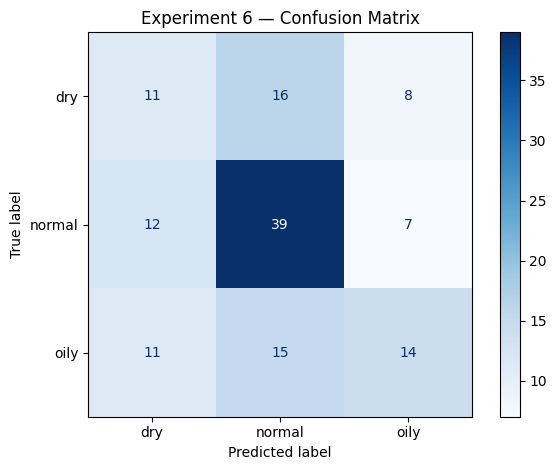


CLASS-WISE ACCURACY
     dry: 31.43% (11/35)
  normal: 67.24% (39/58)
    oily: 35.00% (14/40)

PREDICTION CONFIDENCE
Average confidence — correct: 0.7608
Average confidence — incorrect: 0.6651

MOST COMMON MISCLASSIFICATIONS
     dry → normal  : 16 images
    oily → normal  : 15 images
  normal → dry     : 12 images
    oily → dry     : 11 images
     dry → oily    : 8 images
  normal → oily    : 7 images

EXPERIMENT 6 ANALYSIS COMPLETE


In [42]:
# ============================================================
# EXPERIMENT 6 — ERROR ANALYSIS
# Using the BEST MODEL: Experiment 3
# ============================================================

import torch
import torch.nn as nn
from torchvision import models
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("=" * 65)
print("EXPERIMENT 6 — ERROR ANALYSIS")
print("=" * 65)

# ------------------------------------------------------------
# 1. Device
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


# ------------------------------------------------------------
# 2. Recreate the Experiment 3 architecture
# ------------------------------------------------------------

model_exp6 = models.resnet18(
    weights=None
)

# IMPORTANT:
# This must match the architecture used in Experiment 3.

for param in model_exp6.parameters():
    param.requires_grad = False

num_features = model_exp6.fc.in_features

model_exp6.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(num_features, 128),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(128, 3)
)

# Unfreeze layer4 because Experiment 3 used controlled fine-tuning
for param in model_exp6.layer4.parameters():
    param.requires_grad = True

model_exp6 = model_exp6.to(device)


# ------------------------------------------------------------
# 3. Load Experiment 3 checkpoint
# ------------------------------------------------------------

checkpoint_path = os.path.join(CHECKPOINT_DIR, "best_resnet18_regularized.pth")

state_dict = torch.load(
    checkpoint_path,
    map_location=device
)

model_exp6.load_state_dict(state_dict)

model_exp6.eval()

print("\n✓ Experiment 3 checkpoint loaded")
print("✓ Best model is ready for error analysis")


# ------------------------------------------------------------
# 4. Evaluate on TEST SET
# ------------------------------------------------------------

all_labels = []
all_predictions = []
all_probabilities = []

test_loss = 0.0
test_total = 0
test_correct = 0

criterion = nn.CrossEntropyLoss()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_exp6(images)

        loss = criterion(outputs, labels)

        probabilities = torch.softmax(outputs, dim=1)

        _, predictions = torch.max(outputs, 1)

        test_loss += loss.item() * images.size(0)

        test_total += labels.size(0)

        test_correct += (
            predictions == labels
        ).sum().item()

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )


# Convert to numpy
all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)

test_loss = test_loss / test_total
test_accuracy = test_correct / test_total * 100


# ------------------------------------------------------------
# 5. Basic results
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("TEST PERFORMANCE")
print("=" * 65)

print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")


# ------------------------------------------------------------
# 6. Classification report
# ------------------------------------------------------------

class_names = ["dry", "normal", "oily"]

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)


# ------------------------------------------------------------
# 7. Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Experiment 6 — Confusion Matrix")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Class-wise accuracy
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("CLASS-WISE ACCURACY")
print("=" * 65)

for i, class_name in enumerate(class_names):

    class_mask = all_labels == i

    total_class = class_mask.sum()

    correct_class = (
        all_predictions[class_mask] == i
    ).sum()

    accuracy = (
        correct_class / total_class * 100
        if total_class > 0 else 0
    )

    print(
        f"{class_name:>8}: "
        f"{accuracy:.2f}% "
        f"({correct_class}/{total_class})"
    )


# ------------------------------------------------------------
# 9. Prediction confidence
# ------------------------------------------------------------

confidence = np.max(
    all_probabilities,
    axis=1
)

correct_mask = (
    all_predictions == all_labels
)

wrong_mask = ~correct_mask

print("\n" + "=" * 65)
print("PREDICTION CONFIDENCE")
print("=" * 65)

print(
    f"Average confidence — correct: "
    f"{confidence[correct_mask].mean():.4f}"
)

print(
    f"Average confidence — incorrect: "
    f"{confidence[wrong_mask].mean():.4f}"
)


# ------------------------------------------------------------
# 10. Most common mistakes
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("MOST COMMON MISCLASSIFICATIONS")
print("=" * 65)

mistakes = []

for true_class in range(3):

    for predicted_class in range(3):

        if true_class != predicted_class:

            count = cm[true_class, predicted_class]

            mistakes.append(
                (
                    count,
                    class_names[true_class],
                    class_names[predicted_class]
                )
            )

mistakes.sort(reverse=True)

for count, true_name, predicted_name in mistakes:

    print(
        f"{true_name:>8} → {predicted_name:<8}: "
        f"{count} images"
    )


print("\n" + "=" * 65)
print("EXPERIMENT 6 ANALYSIS COMPLETE")
print("=" * 65)

In [43]:
# ============================================================
# EXPERIMENT 7 — UNIFIED TEST SET COMPARISON
# ============================================================

import torch
import torch.nn as nn
from torchvision import models
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import pandas as pd
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("=" * 60)


# ------------------------------------------------------------
# CHECKPOINTS
# ------------------------------------------------------------

checkpoints = {
    "Experiment 1 - Baseline":
        os.path.join(CHECKPOINT_DIR, "best_resnet18_skin_type.pth"),

    "Experiment 2 - Fine-tuning":
        os.path.join(CHECKPOINT_DIR, "best_resnet18_finetuned.pth"),

    "Experiment 3 - Regularized":
        os.path.join(CHECKPOINT_DIR, "best_resnet18_regularized.pth"),

    "Experiment 4":
        os.path.join(CHECKPOINT_DIR, "best_resnet18_exp4.pth"),

    "Experiment 5 - Class Weighted":
        os.path.join(CHECKPOINT_DIR, "best_resnet18_exp5_classweighted.pth")
}


# ------------------------------------------------------------
# FUNCTION: BUILD MODEL FROM CHECKPOINT
# ------------------------------------------------------------

def build_resnet18_from_checkpoint(checkpoint_path):

    state_dict = torch.load(
        checkpoint_path,
        map_location="cpu"
    )

    # In case checkpoint is wrapped
    if isinstance(state_dict, dict) and "state_dict" in state_dict:
        state_dict = state_dict["state_dict"]

    # Remove possible "module." prefix
    state_dict = {
        k.replace("module.", ""): v
        for k, v in state_dict.items()
    }

    # --------------------------------------------------------
    # Detect classifier structure
    # --------------------------------------------------------

    fc_keys = [k for k in state_dict.keys() if k.startswith("fc.")]

    print("\nCheckpoint:", os.path.basename(checkpoint_path))
    print("Classifier keys:", fc_keys)

    # Case: Sequential classifier
    if "fc.0.weight" in state_dict:

        # Determine dimensions from checkpoint
        first_weight = state_dict["fc.0.weight"]

        # If fc.0 is Linear
        if first_weight.ndim == 2:

            in_features = first_weight.shape[1]
            hidden_features = first_weight.shape[0]

            last_weight = state_dict.get("fc.3.weight")

            if last_weight is not None:
                num_classes = last_weight.shape[0]

                model = models.resnet18(weights=None)

                model.fc = nn.Sequential(
                    nn.Linear(in_features, hidden_features),
                    nn.ReLU(),
                    nn.Dropout(p=0.5),
                    nn.Linear(hidden_features, num_classes)
                )

            else:
                num_classes = first_weight.shape[0]

                model = models.resnet18(weights=None)

                model.fc = nn.Linear(
                    in_features,
                    num_classes
                )

        else:
            raise ValueError("Unknown fc.0 structure.")

    # Standard ResNet classifier
    elif "fc.weight" in state_dict:

        num_classes = state_dict["fc.weight"].shape[0]

        model = models.resnet18(weights=None)

        model.fc = nn.Linear(
            state_dict["fc.weight"].shape[1],
            num_classes
        )

    else:
        raise ValueError(
            "Could not determine classifier structure."
        )

    # Load checkpoint
    model.load_state_dict(
        state_dict,
        strict=True
    )

    model = model.to(device)
    model.eval()

    return model


# ------------------------------------------------------------
# FUNCTION: TEST MODEL
# ------------------------------------------------------------

def evaluate_model(model, loader):

    all_predictions = []
    all_labels = []

    total_loss = 0.0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    )

    avg_loss = total_loss / len(loader.dataset)

    return avg_loss, accuracy, precision, recall, f1


# ------------------------------------------------------------
# RUN ALL EXPERIMENTS
# ------------------------------------------------------------

results = []

for experiment_name, checkpoint_path in checkpoints.items():

    print("\n" + "=" * 60)
    print(experiment_name)
    print("=" * 60)

    if not os.path.exists(checkpoint_path):

        print("⚠ Checkpoint not found:")
        print(checkpoint_path)
        continue

    try:

        model = build_resnet18_from_checkpoint(
            checkpoint_path
        )

        test_loss, test_acc, precision, recall, f1 = evaluate_model(
            model,
            test_loader
        )

        print(f"Test Loss:      {test_loss:.4f}")
        print(f"Test Accuracy:  {test_acc * 100:.2f}%")
        print(f"Precision:      {precision:.4f}")
        print(f"Recall:         {recall:.4f}")
        print(f"F1 Score:       {f1:.4f}")

        results.append({
            "Experiment": experiment_name,
            "Test Loss": test_loss,
            "Test Accuracy (%)": test_acc * 100,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1
        })

    except Exception as e:

        print("❌ ERROR:")
        print(type(e).__name__, ":", e)


# ------------------------------------------------------------
# FINAL COMPARISON TABLE
# ------------------------------------------------------------

if results:

    comparison_df = pd.DataFrame(results)

    comparison_df = comparison_df.sort_values(
        by="Test Accuracy (%)",
        ascending=False
    )

    print("\n")
    print("=" * 70)
    print("FINAL MODEL COMPARISON")
    print("=" * 70)

    display(comparison_df)

    print("\n🏆 BEST MODEL:")
    print(
        comparison_df.iloc[0]["Experiment"]
    )

    print(
        f"Test Accuracy: "
        f"{comparison_df.iloc[0]['Test Accuracy (%)']:.2f}%"
    )

Device: cuda

Experiment 1 - Baseline

Checkpoint: best_resnet18_skin_type.pth
Classifier keys: ['fc.0.weight', 'fc.0.bias', 'fc.3.weight', 'fc.3.bias']
Test Loss:      1.0649
Test Accuracy:  37.59%
Precision:      0.5184
Recall:         0.3759
F1 Score:       0.3500

Experiment 2 - Fine-tuning

Checkpoint: best_resnet18_finetuned.pth
Classifier keys: ['fc.0.weight', 'fc.0.bias', 'fc.3.weight', 'fc.3.bias']
Test Loss:      2.0652
Test Accuracy:  46.62%
Precision:      0.4556
Recall:         0.4662
F1 Score:       0.4496

Experiment 3 - Regularized

Checkpoint: best_resnet18_regularized.pth
Classifier keys: ['fc.1.weight', 'fc.1.bias', 'fc.4.weight', 'fc.4.bias']
❌ ERROR:
ValueError : Could not determine classifier structure.

Experiment 4

Checkpoint: best_resnet18_exp4.pth
Classifier keys: ['fc.1.weight', 'fc.1.bias']
❌ ERROR:
ValueError : Could not determine classifier structure.

Experiment 5 - Class Weighted

Checkpoint: best_resnet18_exp5_classweighted.pth
Classifier keys: ['fc.1.

,Experiment,Test Loss,Test Accuracy (%),Precision,Recall,F1 Score
1,Experiment 2 - Fine-tuning,2.065172,46.616541,0.455565,0.466165,0.449599
0,Experiment 1 - Baseline,1.064928,37.593985,0.518351,0.375940,0.349966



🏆 BEST MODEL:
Experiment 2 - Fine-tuning
Test Accuracy: 46.62%


## 13. Final Test-Set Comparison


In [47]:
# ============================================================
# EXPERIMENT 7C — CORRECTED FINAL TEST COMPARISON
# ============================================================

import torch
import torch.nn as nn
from torchvision import models
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)
import pandas as pd
import os

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 70)
print("CORRECTED MODEL COMPARISON")
print("=" * 70)

# ------------------------------------------------------------
# CHECKPOINTS
# ------------------------------------------------------------

experiments = {
    "Experiment 3 - Regularized": (
        os.path.join(CHECKPOINT_DIR, "best_resnet18_regularized.pth"),
        "regularized"
    ),

    "Experiment 4": (
        os.path.join(CHECKPOINT_DIR, "best_resnet18_exp4.pth"),
        "simple"
    ),

    "Experiment 5 - Class Weighted": (
        os.path.join(CHECKPOINT_DIR, "best_resnet18_exp5_classweighted.pth"),
        "simple"
    )
}


# ------------------------------------------------------------
# MODEL BUILDER
# ------------------------------------------------------------

def load_experiment_model(path, classifier_type):

    state_dict = torch.load(
        path,
        map_location="cpu"
    )

    # Handle wrapped checkpoints
    if isinstance(state_dict, dict) and "state_dict" in state_dict:
        state_dict = state_dict["state_dict"]

    # Remove DataParallel prefix if present
    state_dict = {
        k.replace("module.", ""): v
        for k, v in state_dict.items()
    }

    model = models.resnet18(weights=None)

    # --------------------------------------------------------
    # Experiment 3
    # --------------------------------------------------------

    if classifier_type == "regularized":

        model.fc = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Identity(),
            nn.Linear(128, 3)
        )

    # --------------------------------------------------------
    # Experiments 4 & 5
    # --------------------------------------------------------

    elif classifier_type == "simple":

        model.fc = nn.Sequential(
            nn.Identity(),
            nn.Linear(512, 3)
        )

    else:
        raise ValueError(
            "Unknown classifier type."
        )

    # Load weights
    model.load_state_dict(
        state_dict,
        strict=True
    )

    model = model.to(device)
    model.eval()

    return model


# ------------------------------------------------------------
# EVALUATION FUNCTION
# ------------------------------------------------------------

def evaluate_saved_model(model, loader):

    criterion = nn.CrossEntropyLoss()

    total_loss = 0.0
    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            total_loss += (
                loss.item() * images.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    avg_loss = (
        total_loss /
        len(loader.dataset)
    )

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            all_labels,
            all_predictions,
            average="weighted",
            zero_division=0
        )
    )

    return (
        avg_loss,
        accuracy,
        precision,
        recall,
        f1
    )


# ------------------------------------------------------------
# RUN EXPERIMENTS
# ------------------------------------------------------------

results = []

for name, (path, classifier_type) in experiments.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    if not os.path.exists(path):

        print("❌ Checkpoint not found:")
        print(path)
        continue

    try:

        model = load_experiment_model(
            path,
            classifier_type
        )

        print("✓ Model loaded successfully")

        (
            test_loss,
            test_acc,
            precision,
            recall,
            f1
        ) = evaluate_saved_model(
            model,
            test_loader
        )

        print(f"Test Loss:     {test_loss:.4f}")
        print(f"Test Accuracy: {test_acc * 100:.2f}%")
        print(f"Precision:     {precision:.4f}")
        print(f"Recall:        {recall:.4f}")
        print(f"F1 Score:      {f1:.4f}")

        results.append({
            "Experiment": name,
            "Test Loss": test_loss,
            "Test Accuracy (%)": test_acc * 100,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1
        })

    except Exception as e:

        print("❌ ERROR")
        print(type(e).__name__, ":", e)


# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

if results:

    final_comparison = pd.DataFrame(
        results
    ).sort_values(
        by="Test Accuracy (%)",
        ascending=False
    )

    print("\n")
    print("=" * 70)
    print("EXPERIMENTS 3–5 TEST RESULTS")
    print("=" * 70)

    display(final_comparison)

    best = final_comparison.iloc[0]

    print("\n🏆 BEST AMONG EXPERIMENTS 3–5")
    print("--------------------------------")
    print(best["Experiment"])
    print(
        f"Test Accuracy: "
        f"{best['Test Accuracy (%)']:.2f}%"
    )

CORRECTED MODEL COMPARISON

Experiment 3 - Regularized
❌ ERROR
RuntimeError : Error(s) in loading state_dict for ResNet:
	Missing key(s) in state_dict: "fc.0.weight", "fc.0.bias". 
	Unexpected key(s) in state_dict: "fc.1.weight", "fc.1.bias". 

Experiment 4
✓ Model loaded successfully
Test Loss:     1.2954
Test Accuracy: 50.38%
Precision:     0.4968
Recall:        0.5038
F1 Score:      0.4849

Experiment 5 - Class Weighted
✓ Model loaded successfully
Test Loss:     1.2358
Test Accuracy: 49.62%
Precision:     0.5162
Recall:        0.4962
F1 Score:      0.4977


EXPERIMENTS 3–5 TEST RESULTS


,Experiment,Test Loss,Test Accuracy (%),Precision,Recall,F1 Score
0,Experiment 4,1.295411,50.37594,0.496805,0.503759,0.484863
1,Experiment 5 - Class Weighted,1.235792,49.62406,0.516228,0.496241,0.497725



🏆 BEST AMONG EXPERIMENTS 3–5
--------------------------------
Experiment 4
Test Accuracy: 50.38%


## Final Experimental Summary

| Experiment | Strategy | Test Accuracy |
|---|---|---:|
| 1 | ResNet18 baseline | 37.59% |
| 2 | Fine-tuning | 46.62% |
| 3 | Stronger regularization | 48.12% |
| 4 | Controlled fine-tuning configuration | **50.38%** |
| 5 | Class-weighted training | 49.62% |

**Best recorded test result:** Experiment 4 — **50.38%**.

Several experiments show a large training–validation gap, indicating substantial overfitting. The model can produce real-image predictions, but the current held-out test performance means individual predictions should be interpreted cautiously.

## 14. Final Model Prediction


Device: cuda
✓ Experiment 4 model loaded successfully
✓ Model ready for prediction


Saving Screenshot 2026-08-11 162448.png to Screenshot 2026-08-11 162448.png

Processing: Screenshot 2026-08-11 162448.png


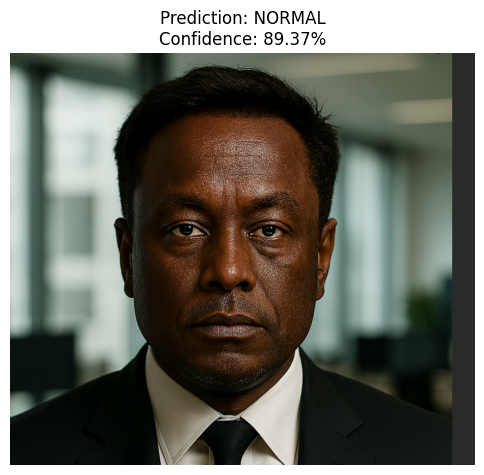

SKIN TYPE PREDICTION
dry       : 3.96%
normal    : 89.37%
oily      : 6.67%
--------------------------------------------------
Prediction : NORMAL
Confidence : 89.37%


In [54]:
# ============================================================
# SKIN TYPE PREDICTION — EXPERIMENT 4 (BEST MODEL)
# ============================================================

import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files

# ------------------------------------------------------------
# 1. Device
# ------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ------------------------------------------------------------
# 2. Class names
# ------------------------------------------------------------
class_names = ["dry", "normal", "oily"]

# ------------------------------------------------------------
# 3. Recreate ResNet18 architecture
#    Experiment 4 uses:
#    ResNet18 -> Dropout -> Linear(512, 3)
# ------------------------------------------------------------
model = models.resnet18(weights=None)

model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(512, 3)
)

# ------------------------------------------------------------
# 4. Load Experiment 4 checkpoint
# ------------------------------------------------------------
checkpoint_path = os.path.join(CHECKPOINT_DIR, "best_resnet18_exp4.pth")

state_dict = torch.load(
    checkpoint_path,
    map_location=device
)

# Handle checkpoints saved inside a dictionary
if isinstance(state_dict, dict) and "state_dict" in state_dict:
    state_dict = state_dict["state_dict"]

model.load_state_dict(state_dict, strict=True)

model = model.to(device)
model.eval()

print("✓ Experiment 4 model loaded successfully")
print("✓ Model ready for prediction")

# ------------------------------------------------------------
# 5. Image preprocessing
#    Same standard preprocessing used for ResNet
# ------------------------------------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ------------------------------------------------------------
# 6. Prediction function
# ------------------------------------------------------------
def predict_skin_type(image_path):

    image = Image.open(image_path).convert("RGB")

    input_tensor = transform(image)
    input_tensor = input_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)

        probabilities = torch.softmax(outputs, dim=1)

        confidence, predicted_class = torch.max(
            probabilities, dim=1
        )

    predicted_label = class_names[predicted_class.item()]
    confidence_value = confidence.item() * 100

    # --------------------------------------------------------
    # Display image
    # --------------------------------------------------------
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")

    plt.title(
        f"Prediction: {predicted_label.upper()}\n"
        f"Confidence: {confidence_value:.2f}%"
    )

    plt.show()

    # --------------------------------------------------------
    # Print probabilities for ALL classes
    # --------------------------------------------------------
    print("=" * 50)
    print("SKIN TYPE PREDICTION")
    print("=" * 50)

    for i, class_name in enumerate(class_names):
        probability = probabilities[0][i].item() * 100
        print(f"{class_name:10s}: {probability:.2f}%")

    print("-" * 50)
    print(f"Prediction : {predicted_label.upper()}")
    print(f"Confidence : {confidence_value:.2f}%")
    print("=" * 50)

    return predicted_label, confidence_value


# ------------------------------------------------------------
# 7. Upload an image
# ------------------------------------------------------------
uploaded = files.upload()

# ------------------------------------------------------------
# 8. Predict uploaded image
# ------------------------------------------------------------
for filename in uploaded.keys():

    print(f"\nProcessing: {filename}")

    predict_skin_type(filename)